# ACV refrigerant-leak localisation — EDA

Seven case files, 8 cars each, 30 s telemetry; exactly one car per file is leaking, and
the faulty car is published for the six Train cases only. Scoring is linear rank decay,
`(n − (r − 1)) / n`, so the deliverable is a full 8-car ranking, not a single pick.

This notebook only **looks**: shapes, plots and summary tables. It deliberately stops at
laying candidate ranking rules next to the 0.5625 random-ranking baseline — picking one is
modelling work, and with six labelled cases it is far too easy to pick on luck.

Loading, statistics and the scoring harness live in `acv_features.py`; the plots in
`acv_plots.py`. Both read each file's own headers, and fold every alias onto one
canonical parameter name (see §1), because the parameter set and naming differ between
files. `.xlsx` parsing is mirrored to Parquet under `.cache/` on first load (see
`load_case`) — the first run of this notebook pays the full `openpyxl` cost once
(dominated by case 04's 483 columns, ~2 min), every run after that loads in well under a
second.

In [75]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import acv_features as af
import acv_plots as ap

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

af.ALL_CASES, af.label_map()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(['acv_case_01.xlsx',
  'acv_case_02.xlsx',
  'acv_case_03.xlsx',
  'acv_case_04.xlsx',
  'acv_case_05.xlsx',
  'acv_case_06.xlsx',
  'acv_test_case.xlsx'],
 {'acv_case_01.xlsx': '01',
  'acv_case_02.xlsx': '02',
  'acv_case_03.xlsx': '03',
  'acv_case_04.xlsx': '01',
  'acv_case_05.xlsx': '04',
  'acv_case_06.xlsx': '06'})

## 1. Shapes and schema

The main trap in this dataset. `acv_case_04.xlsx` carries 63 parameters per car against
everyone else's 8, column order varies between files, and several files name the *same*
measurement differently -- cases 05/06's outdoor reading, and 6 of case 04's parameters
(`Passenger Cabin Temperature Detected Value` for indoor temp, `ACV Control Mode` for
setting mode, and so on). `PARAM_ALIASES` folds all of this onto 8 canonical names, which
is what this notebook works with throughout -- since the Test case follows the standard
67-column schema, case 04's ~55 remaining parameters with no equivalent elsewhere are not
explored here; they cannot be used at inference time regardless of what they show.


In [76]:
shapes = af.case_shapes()
shapes

,case,n_rows,n_cols,n_cars,params_per_car,first_car_col,start,end,duration_h,median_dt_s,shared_params_present
0,acv_case_01.xlsx,6999,67,8,8,01,2023-05-18 00:00:00,2023-05-21 20:49:30,92.825000,30.0,8
1,acv_case_02.xlsx,9187,67,8,8,01,2020-07-09 00:00:00,2020-07-12 23:35:00,95.583333,30.0,8
2,acv_case_03.xlsx,8310,67,8,8,01,2021-09-30 05:16:00,2021-10-03 23:59:30,90.725000,30.0,8
3,acv_case_04.xlsx,22262,483,8,63,01,2023-08-15 07:06:50,2023-08-18 20:41:00,85.569444,10.0,6
4,acv_case_05.xlsx,6972,67,8,8,01,2021-03-03 06:19:00,2021-03-06 23:59:30,89.675000,30.0,8
5,acv_case_06.xlsx,3263,67,8,8,01,2020-07-06 08:42:00,2020-07-08 23:59:30,63.291667,30.0,8
6,acv_test_case.xlsx,9082,67,8,8,01,2021-06-24 00:00:00,2021-06-27 23:59:30,95.991667,30.0,8


In [77]:
# Per-file parameter sets, canonicalised, and what they have in common.
param_sets = {}
for case in af.ALL_CASES:
    cols = af.car_columns(af.load_case(case))
    param_sets[case] = {af.canonical_param(c.split(" - ", 1)[1])
                        for cols_ in cols.values() for c in cols_}

presence = pd.DataFrame(
    {case: {p: p in s for p in sorted(set().union(*param_sets.values()))}
     for case, s in param_sets.items()}
)
shared = set.intersection(*param_sets.values())
print(f"{len(shared)} parameters shared by all {len(param_sets)} files (of {len(af.SHARED_PARAMS)} candidates)")
presence.loc[sorted(set(af.SHARED_PARAMS) | shared)]

6 parameters shared by all 7 files (of 8 candidates)


,acv_case_01.xlsx,acv_case_02.xlsx,acv_case_03.xlsx,acv_case_04.xlsx,acv_case_05.xlsx,acv_case_06.xlsx,acv_test_case.xlsx
ACV Control Temperature (Cooling),True,True,True,True,True,True,True
ACV Control Temperature (Heating),True,True,True,False,True,True,True
ACV Information Valid,True,True,True,False,True,True,True
ACV Running Mode,True,True,True,True,True,True,True
ACV Setting Mode,True,True,True,True,True,True,True
Indoor Average Temperature,True,True,True,True,True,True,True
Load Halved,True,True,True,True,True,True,True
Outdoor Average Temperature,True,True,True,True,True,True,True


In [78]:
# The car ids each file uses, in header order — these are the exact strings a
# `ranked_cars` submission must contain.
pd.DataFrame({
    case: {"cars": "|".join(af.car_columns(af.load_case(case)))}
    for case in af.ALL_CASES
}).T

,cars
acv_case_01.xlsx,01|02|03|04|05|06|07|08
acv_case_02.xlsx,01|02|03|04|05|06|07|08
acv_case_03.xlsx,01|02|03|04|05|06|07|08
acv_case_04.xlsx,01|02|03|04|05|06|07|08
acv_case_05.xlsx,01|02|03|04|05|06|07|08
acv_case_06.xlsx,01|02|03|04|05|06|07|08
acv_test_case.xlsx,01|02|03|04|05|06|07|08


## 2. One case, read properly

Case 01 (faulty car `01`) end to end before anything is aggregated: raw traces, then the
same traces as residuals against the leave-one-out median of the other seven cars, then
the categorical parameters as regime strips. The residual view is the one that matters —
weather and the train-wide control schedule move all 8 traces together and cancel out of
it.

In [79]:
case = "acv_case_01.xlsx"
long01 = af.with_majority_reference(af.with_train_reference(af.to_long(case)))
long01.head()

,case,Time,car,param,value,raw,ref_mean,ref,resid,majority_raw,is_majority
0,acv_case_01.xlsx,2023-05-18 00:00:00,01,ACV Control Temperature (Cooling),25.0,25.0,25.0,25.0,0.0,25.0,1.0
1,acv_case_01.xlsx,2023-05-18 00:00:30,01,ACV Control Temperature (Cooling),25.0,25.0,25.0,25.0,0.0,25.0,1.0
2,acv_case_01.xlsx,2023-05-18 00:01:00,01,ACV Control Temperature (Cooling),25.0,25.0,25.0,25.0,0.0,25.0,1.0
3,acv_case_01.xlsx,2023-05-18 00:01:30,01,ACV Control Temperature (Cooling),25.0,25.0,25.0,25.0,0.0,25.0,1.0
4,acv_case_01.xlsx,2023-05-18 00:02:00,01,ACV Control Temperature (Cooling),25.0,25.0,25.0,25.0,0.0,25.0,1.0


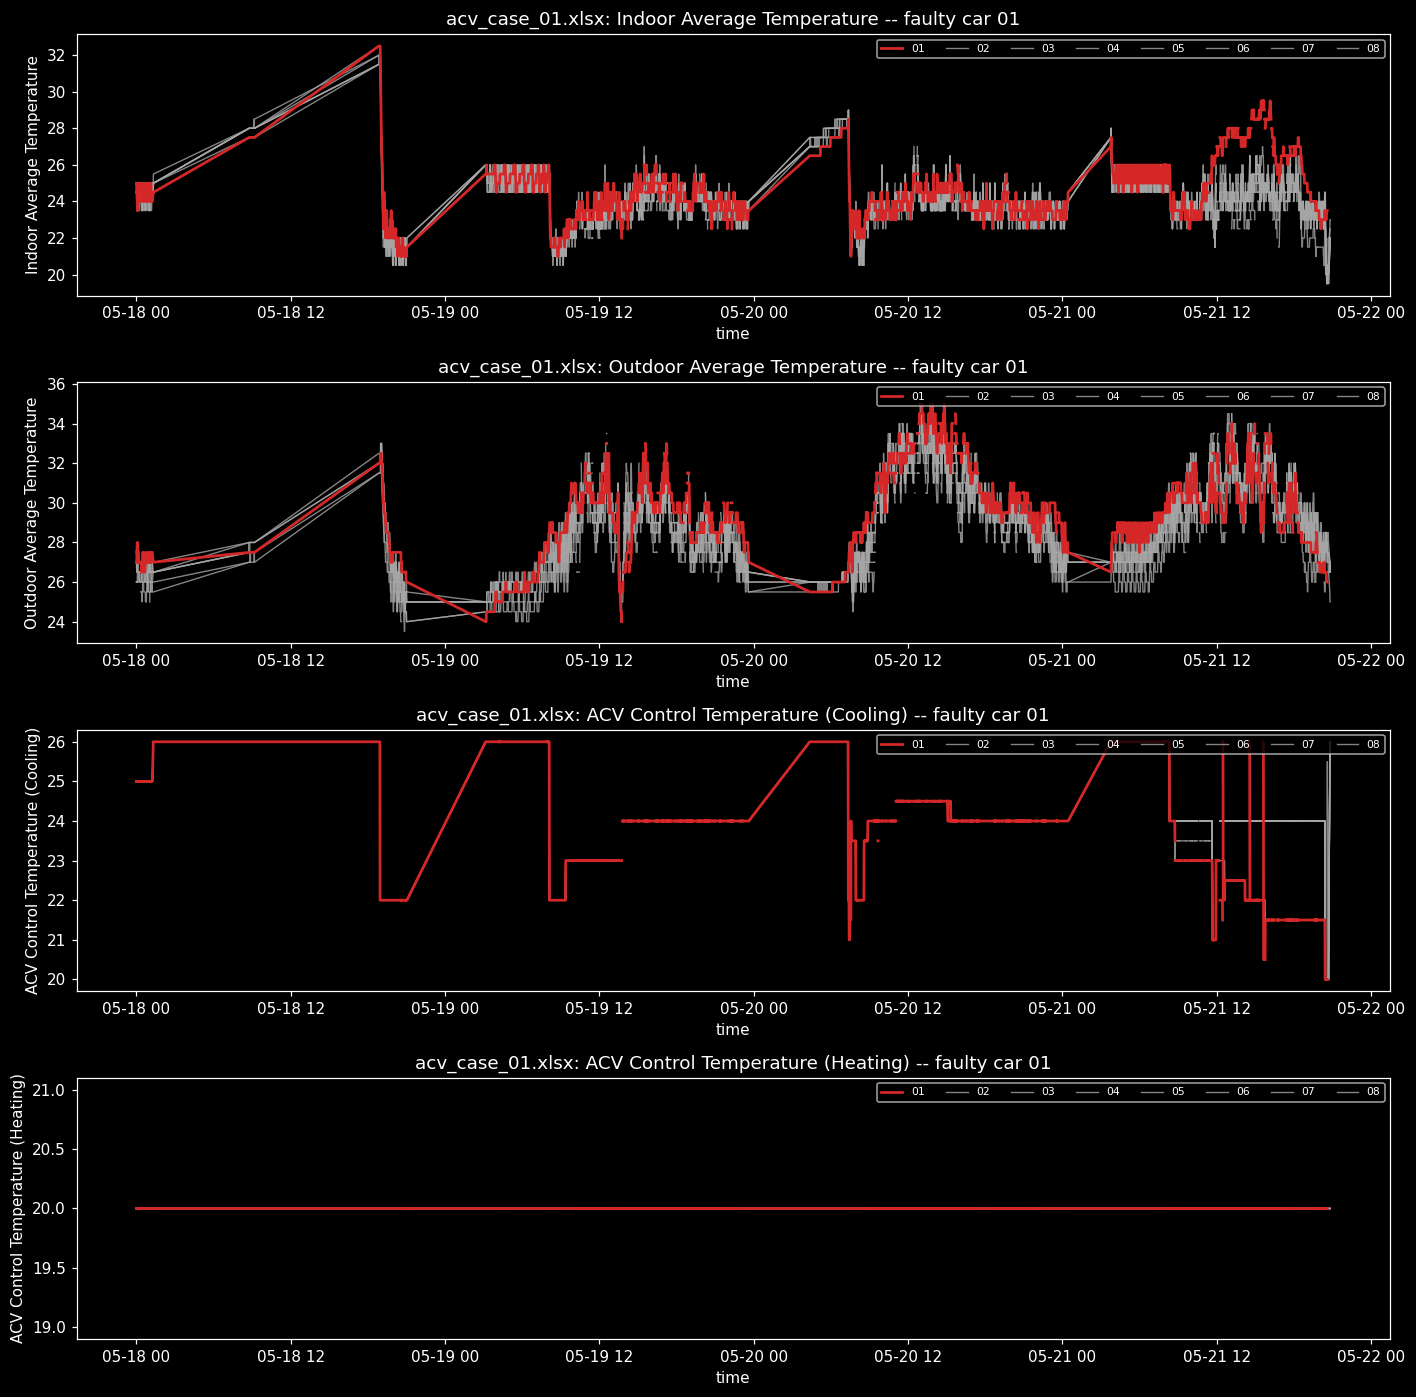

In [80]:
fig, axes = plt.subplots(len(af.NUMERIC_PARAMS), 1,
                         figsize=(13, 3.2 * len(af.NUMERIC_PARAMS)))
for ax, param in zip(axes, af.NUMERIC_PARAMS):
    ap.plot_case_timeline(case, param=param, long=long01, ax=ax)
fig.tight_layout()

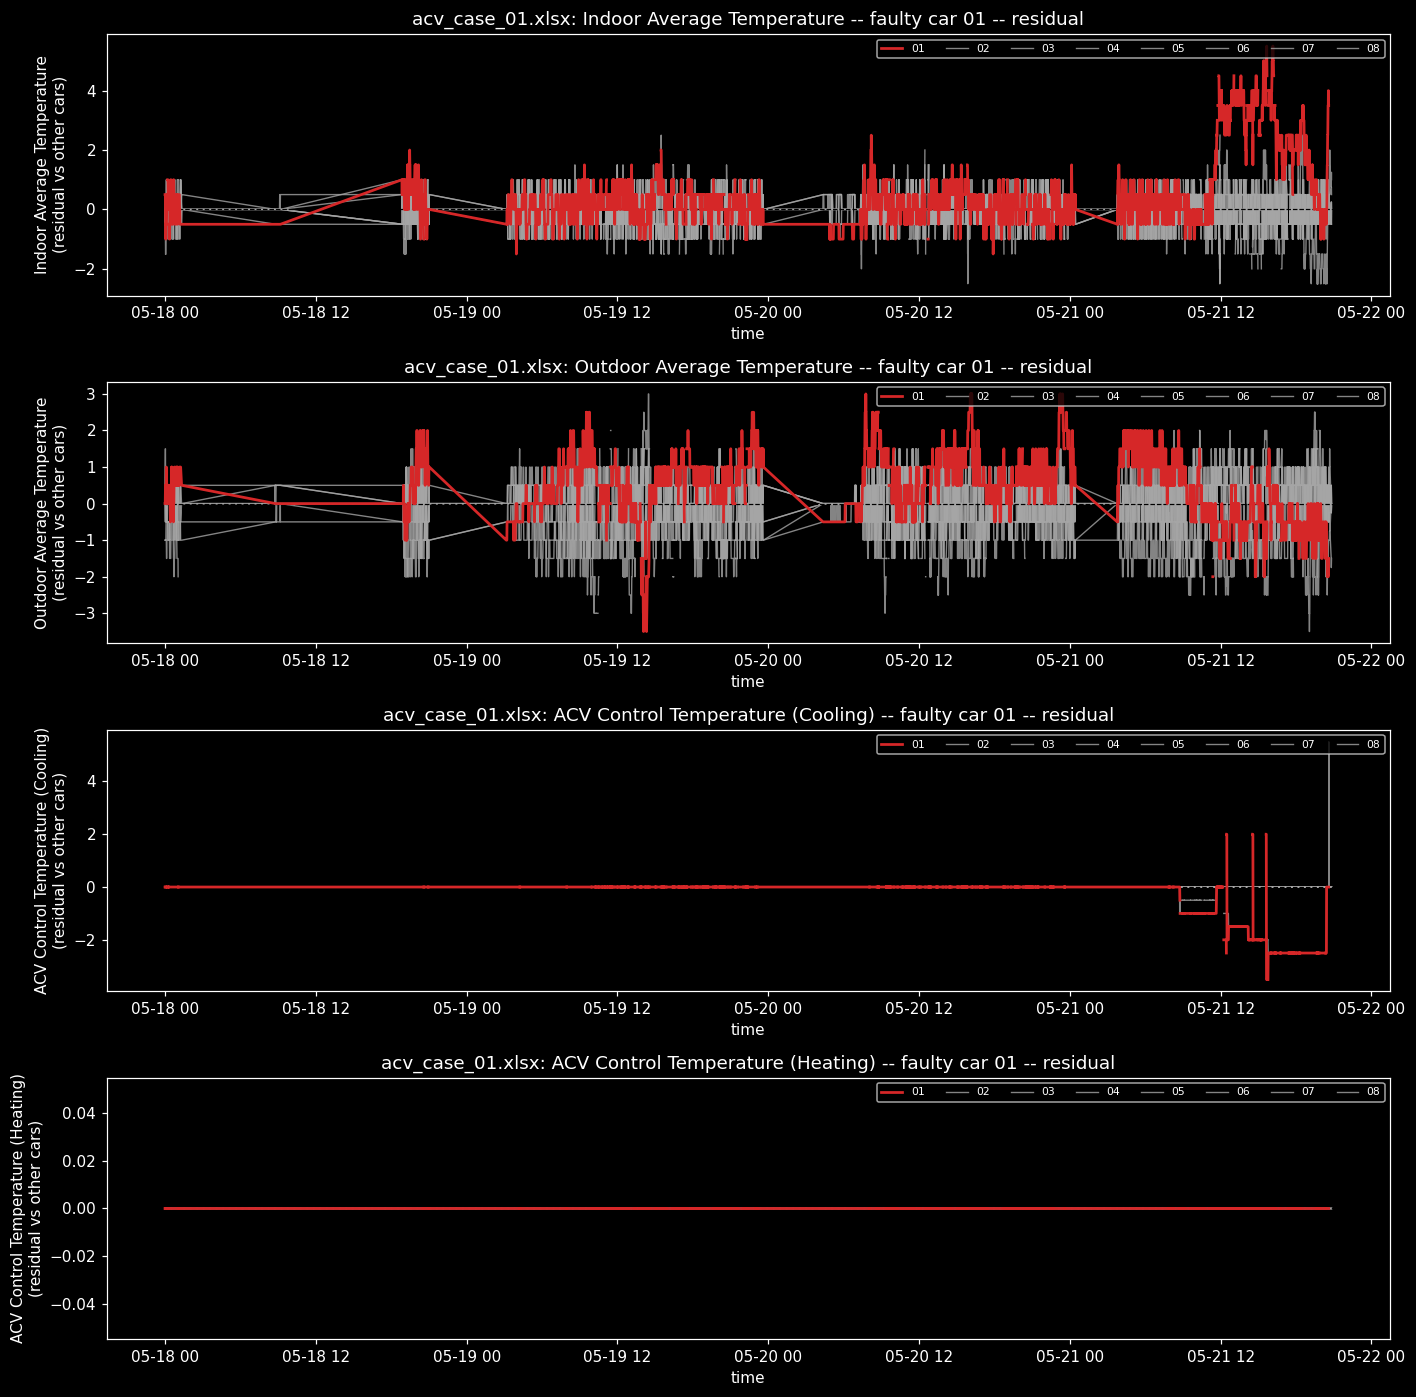

In [81]:
fig, axes = plt.subplots(len(af.NUMERIC_PARAMS), 1,
                         figsize=(13, 3.2 * len(af.NUMERIC_PARAMS)))
for ax, param in zip(axes, af.NUMERIC_PARAMS):
    ap.plot_residual_timeline(case, param=param, long=long01, ax=ax)
fig.tight_layout()

### Regimes: which car is in which state, and when

`plot_regime_strip` is a car x time image, one coloured band per state, for a single
categorical parameter — the direct replacement for an 8-line overplotted staircase. A
black tick marks every instant where that car's state differs from the train-wide
*majority* state at that moment (see `with_majority_reference`); `plot_mode_heatmap`
stacks all four categorical parameters this way for one case.

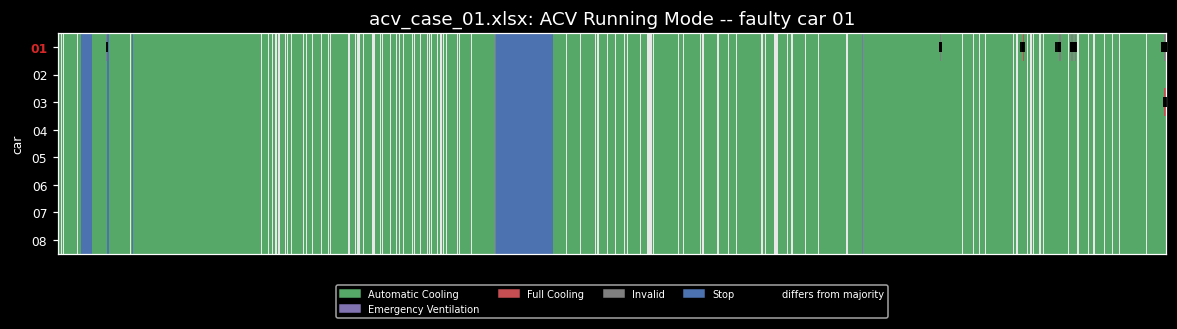

In [82]:
ap.plot_regime_strip(case, param="ACV Running Mode", long=long01);

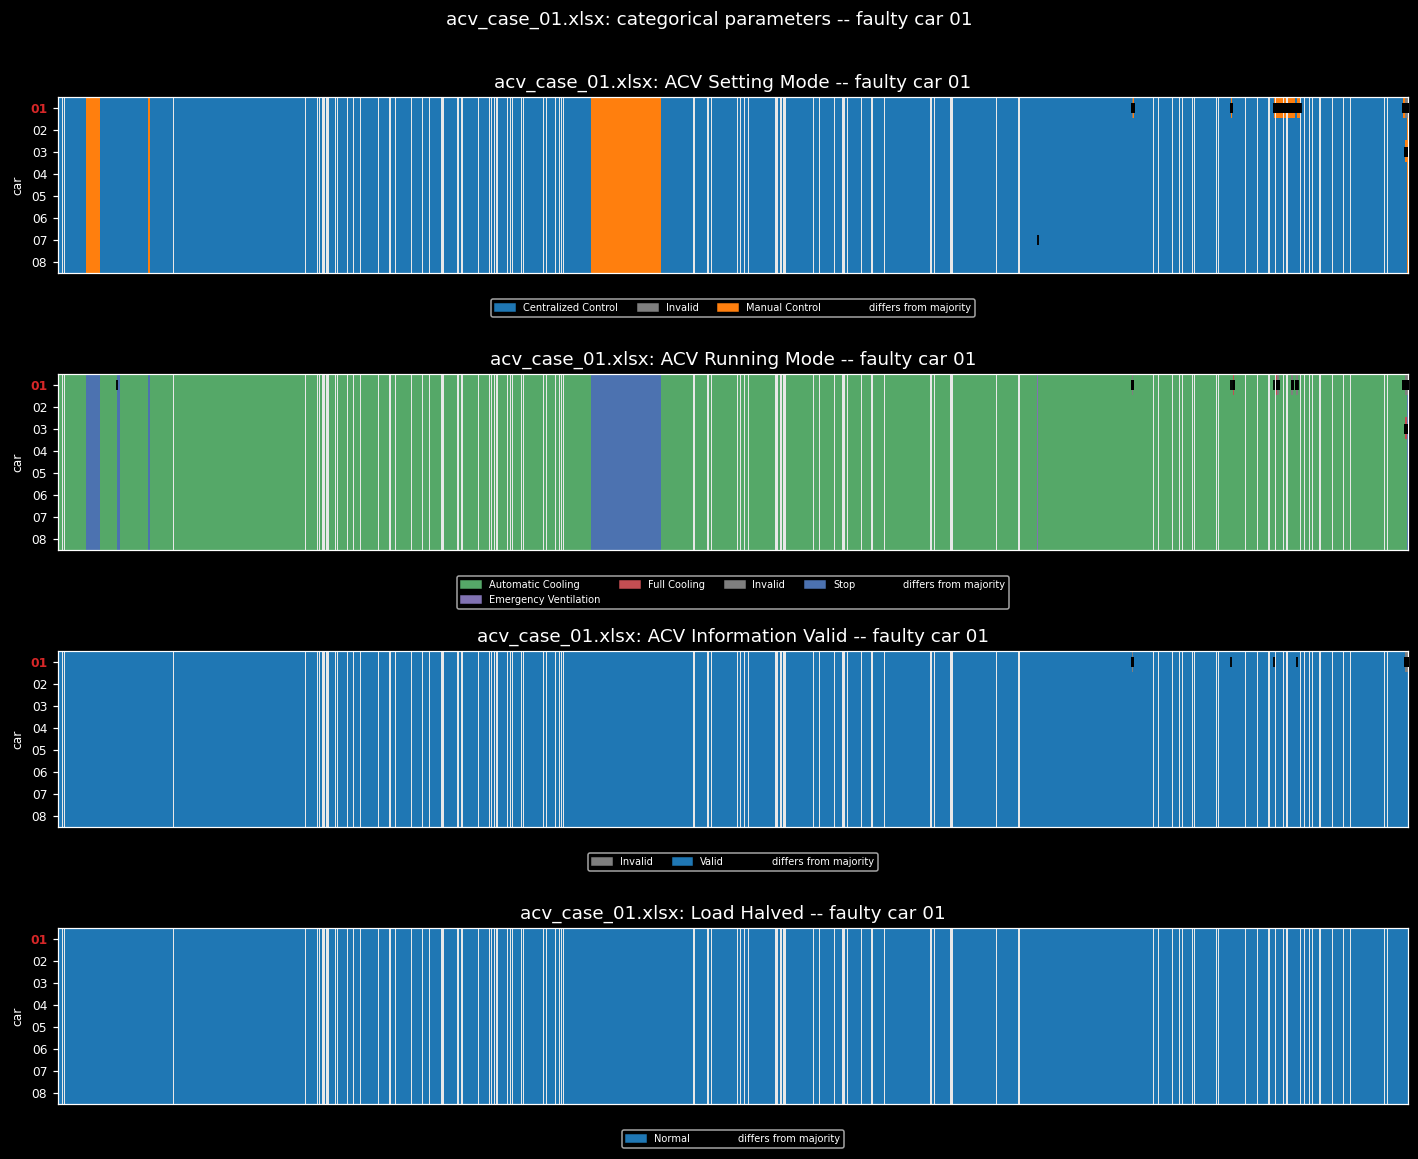

In [83]:
ap.plot_mode_heatmap(case, long=long01);

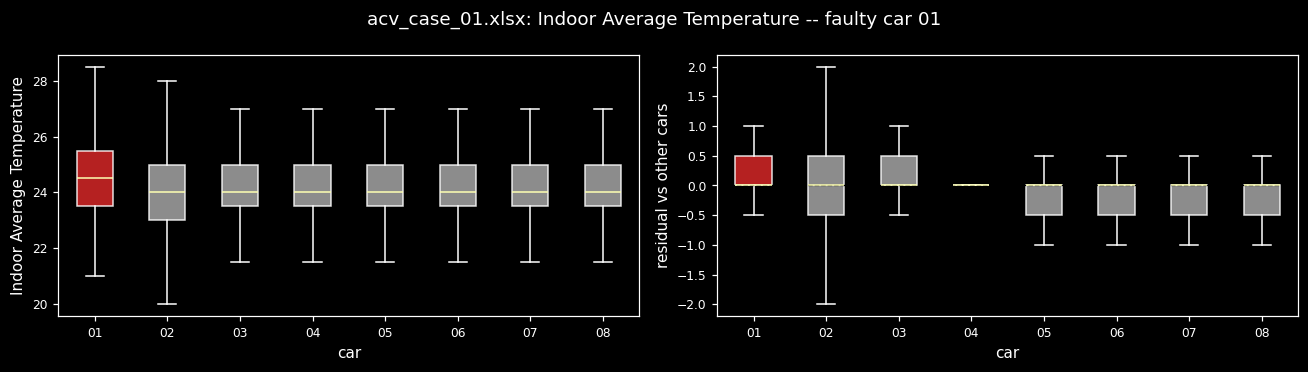

In [84]:
ap.plot_car_distributions(case, "Indoor Average Temperature", long=long01);

## 3. All cases side by side

Six labelled faults in six different files, each with its own weather and schedule. The
question these panels answer is whether the red trace/row stands out the *same way*
across cases — a signature that only appears in one or two of them will not survive to the
held-out case.

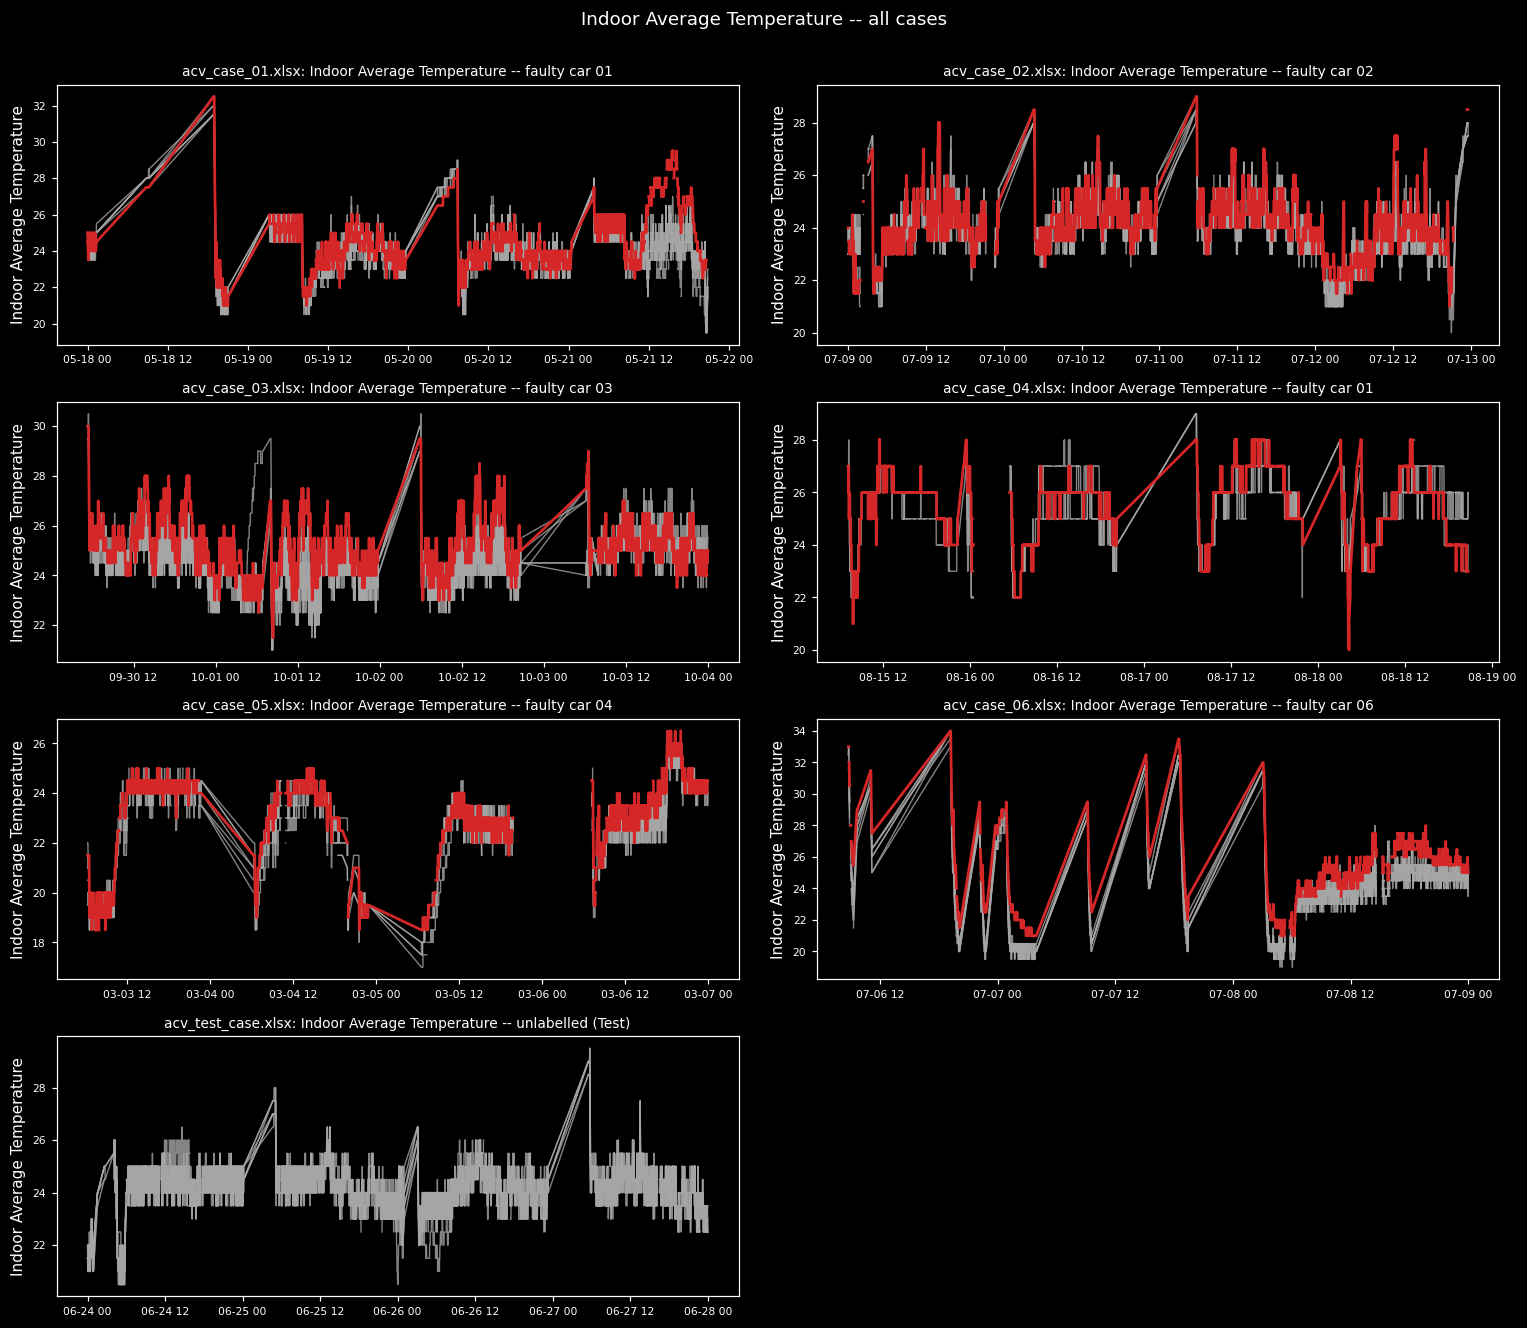

In [85]:
ap.plot_case_grid("Indoor Average Temperature", residual=False);

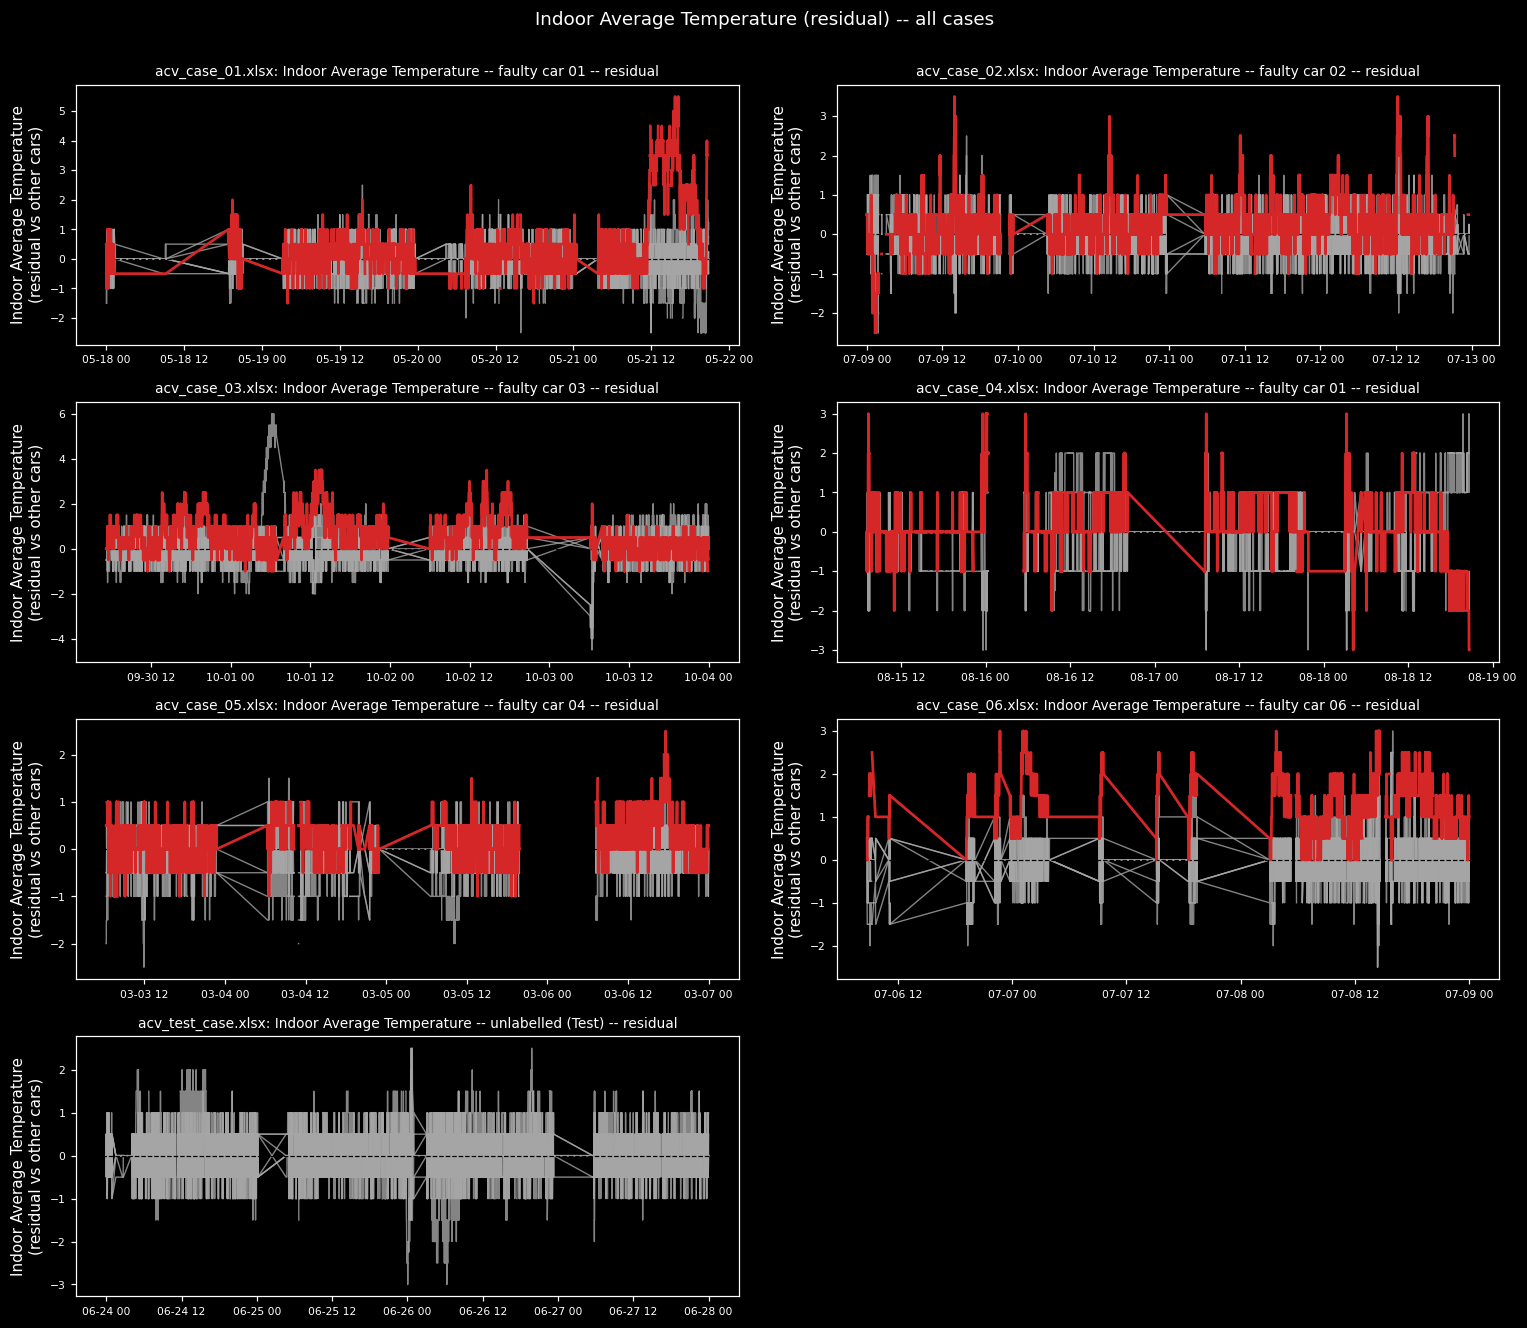

In [86]:
ap.plot_case_grid("Indoor Average Temperature", residual=True);

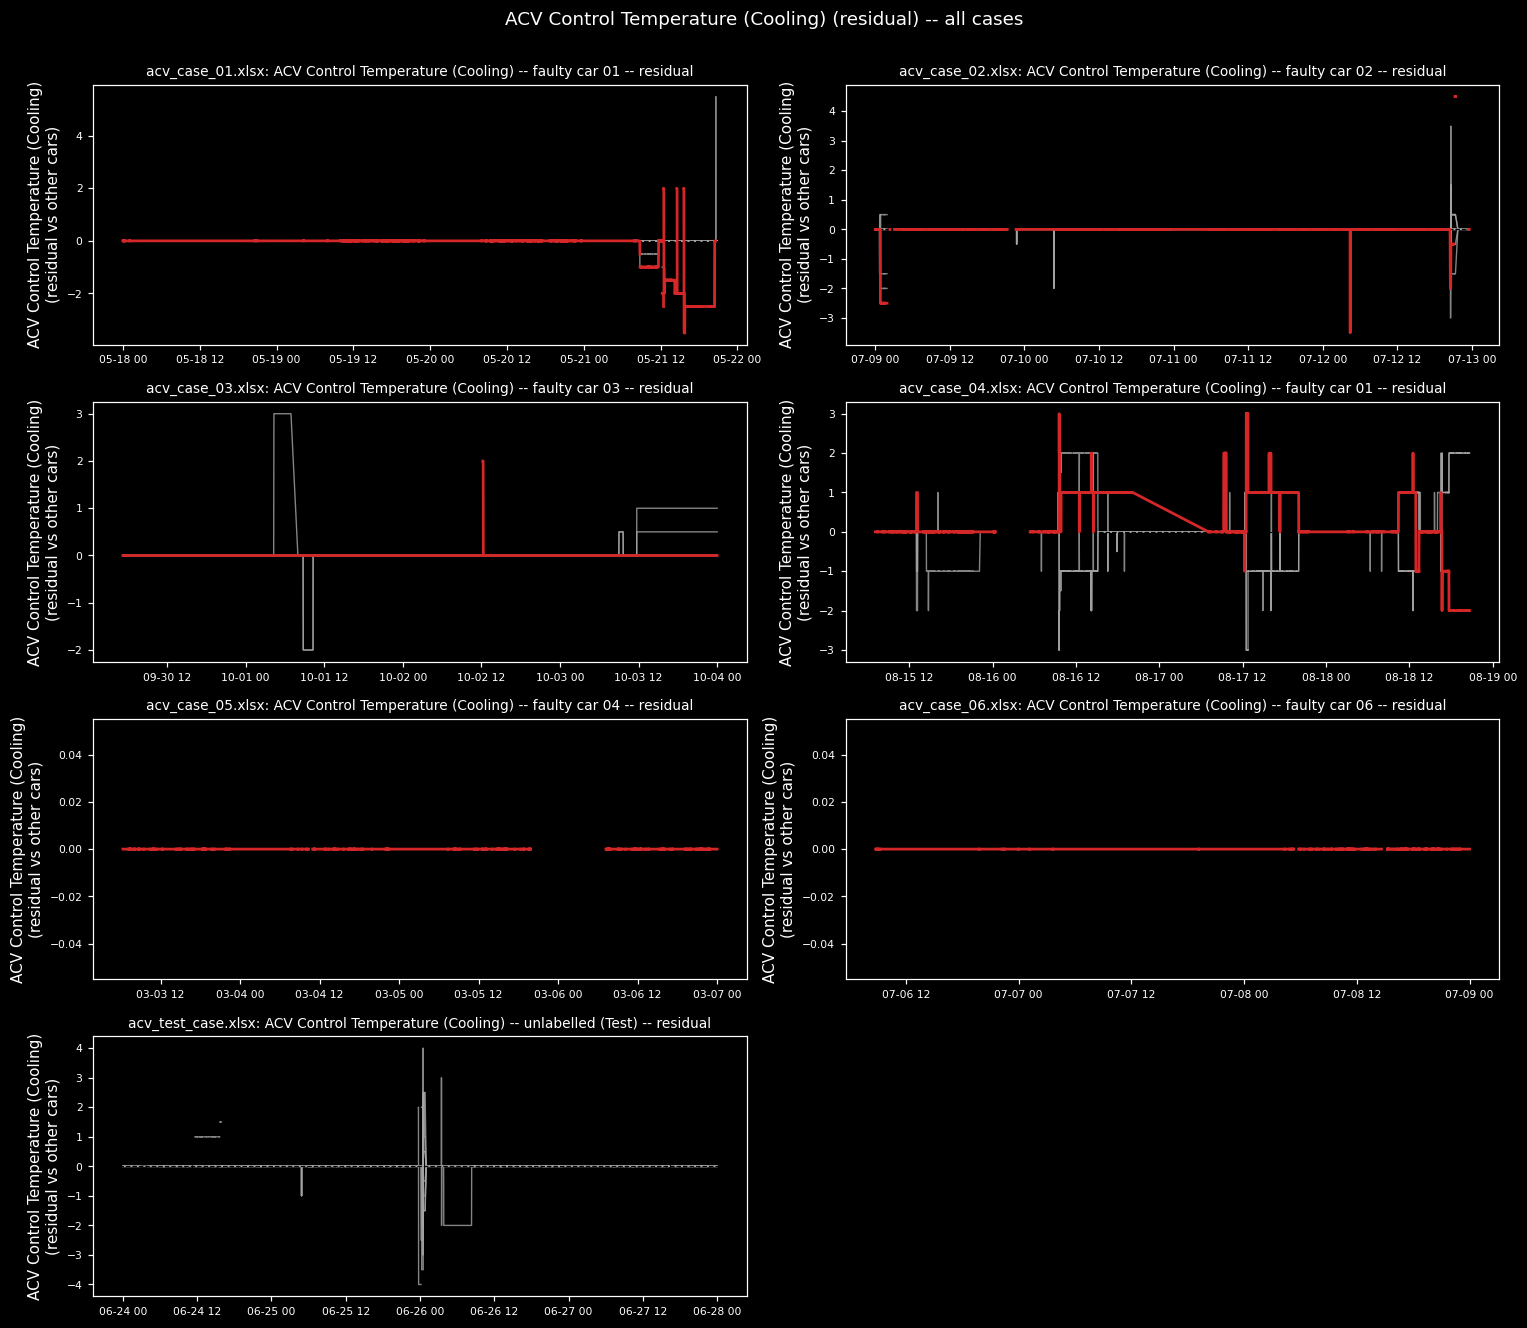

In [87]:
ap.plot_case_grid("ACV Control Temperature (Cooling)", residual=True);

C:\Users\keith\PycharmProjects\NebulaX-Hackathon-ProblemStatement\PS3\ACV subproblem\acv_plots.py:253: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.imshow(codes, aspect="auto", interpolation="nearest",
C:\Users\keith\PycharmProjects\NebulaX-Hackathon-ProblemStatement\PS3\ACV subproblem\acv_plots.py:253: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.imshow(codes, aspect="auto", interpolation="nearest",


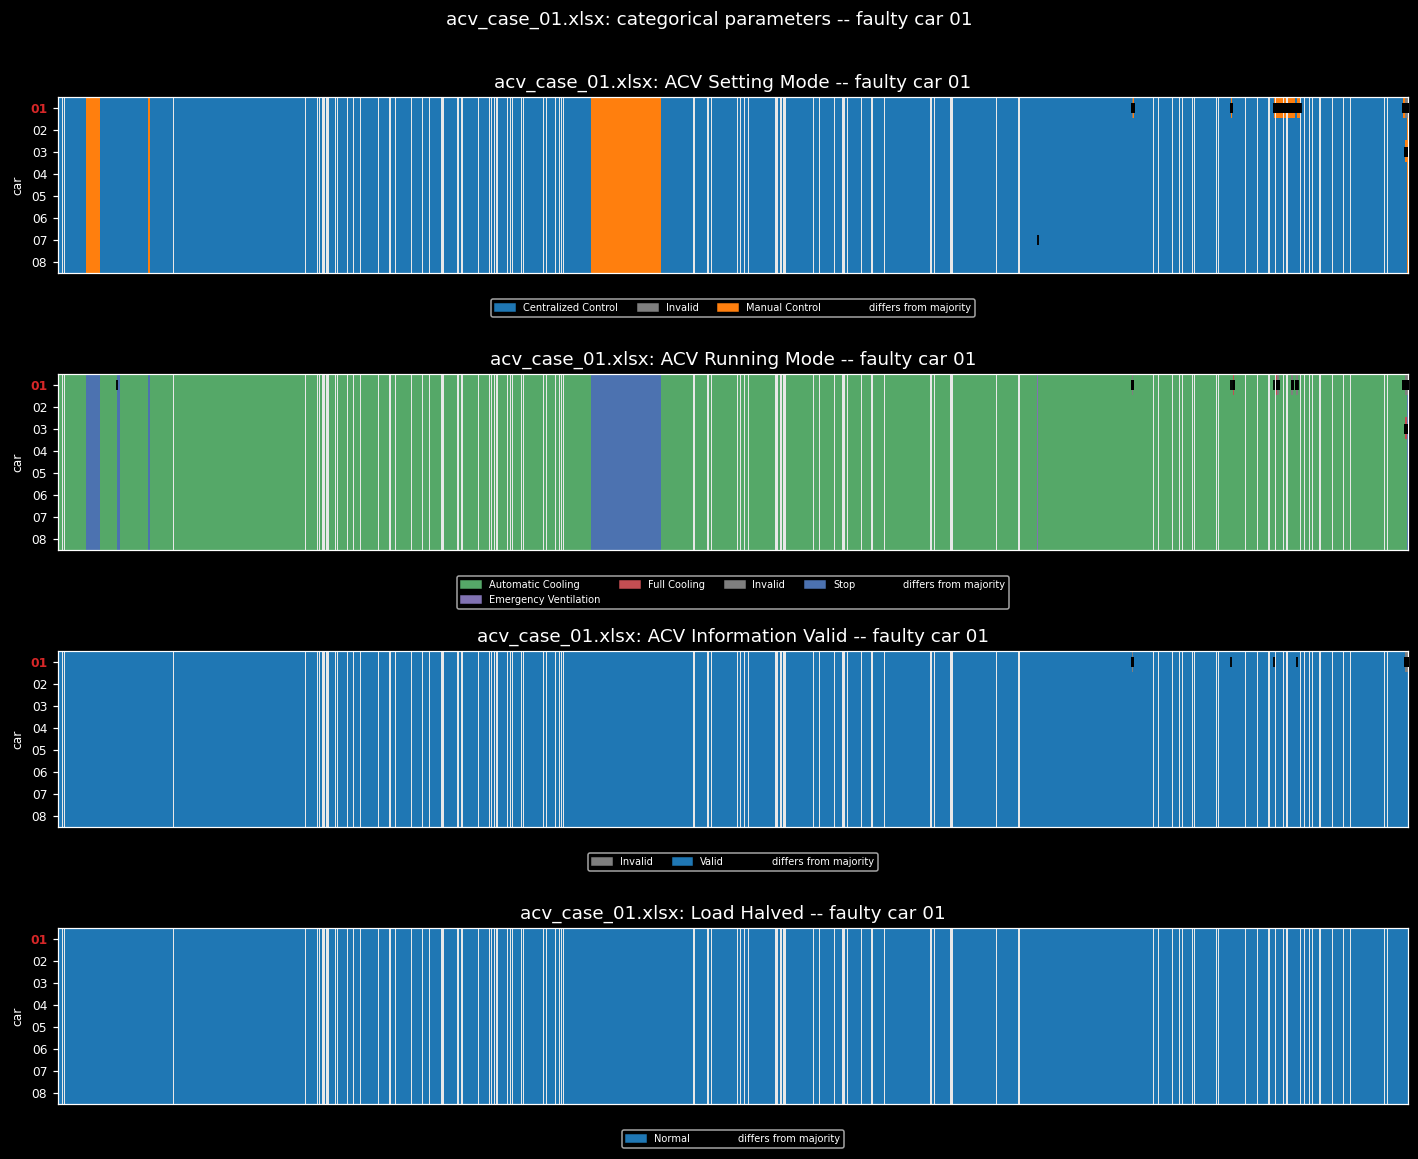

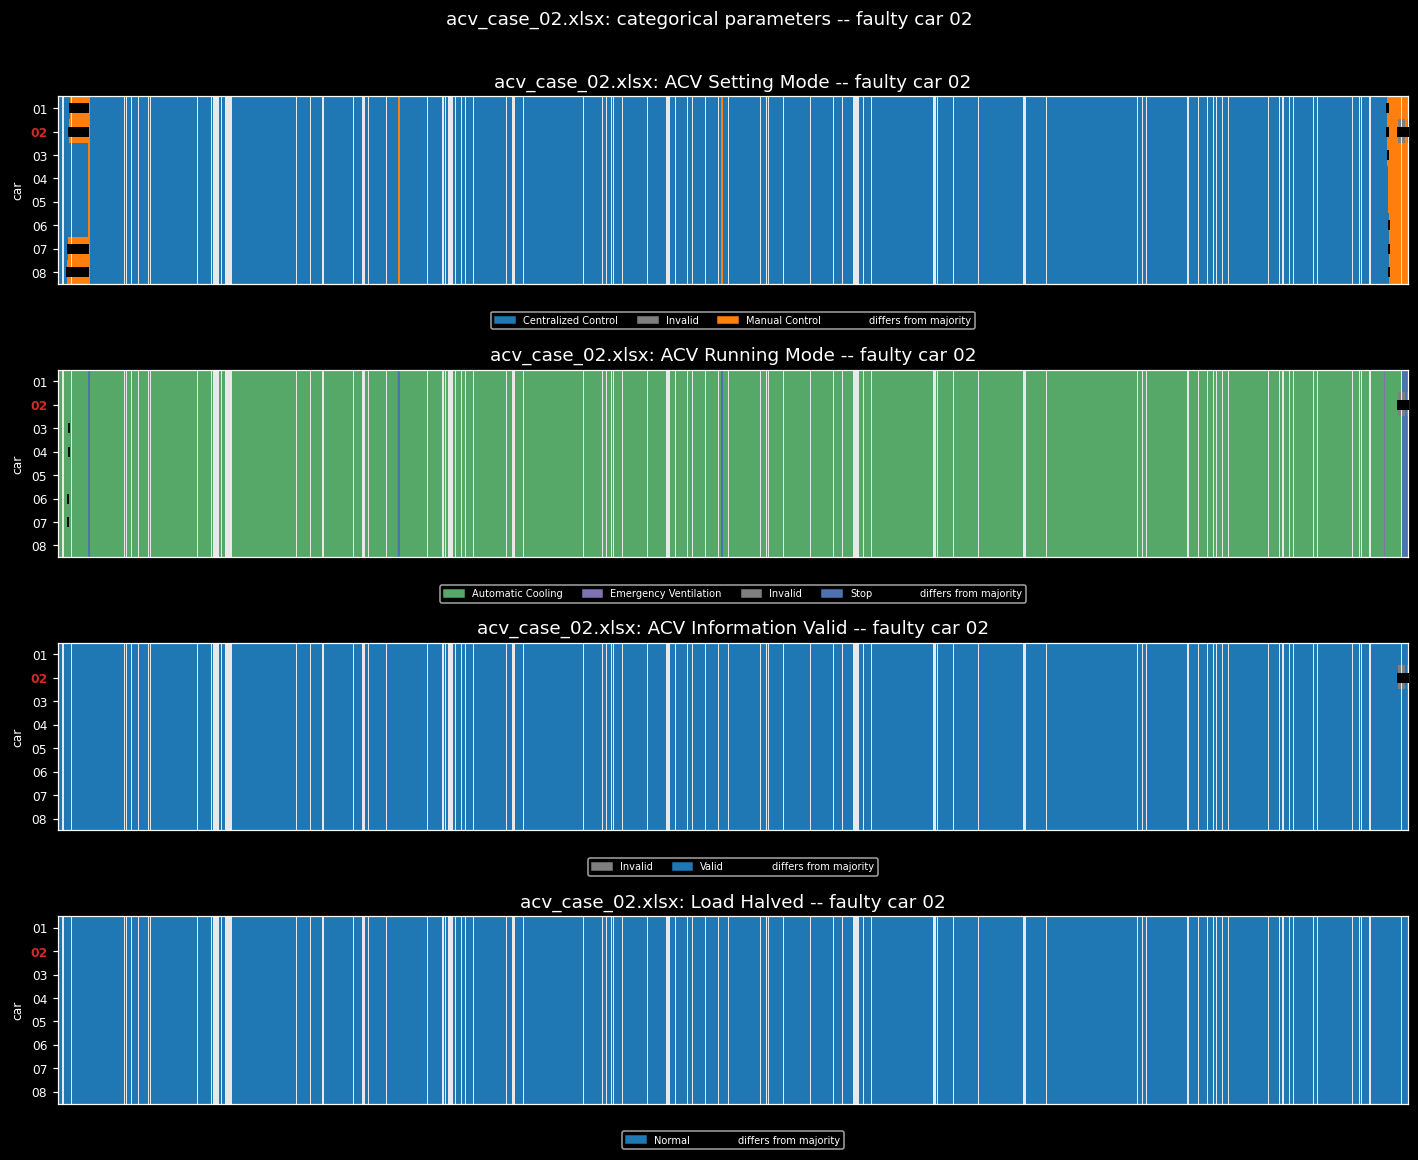

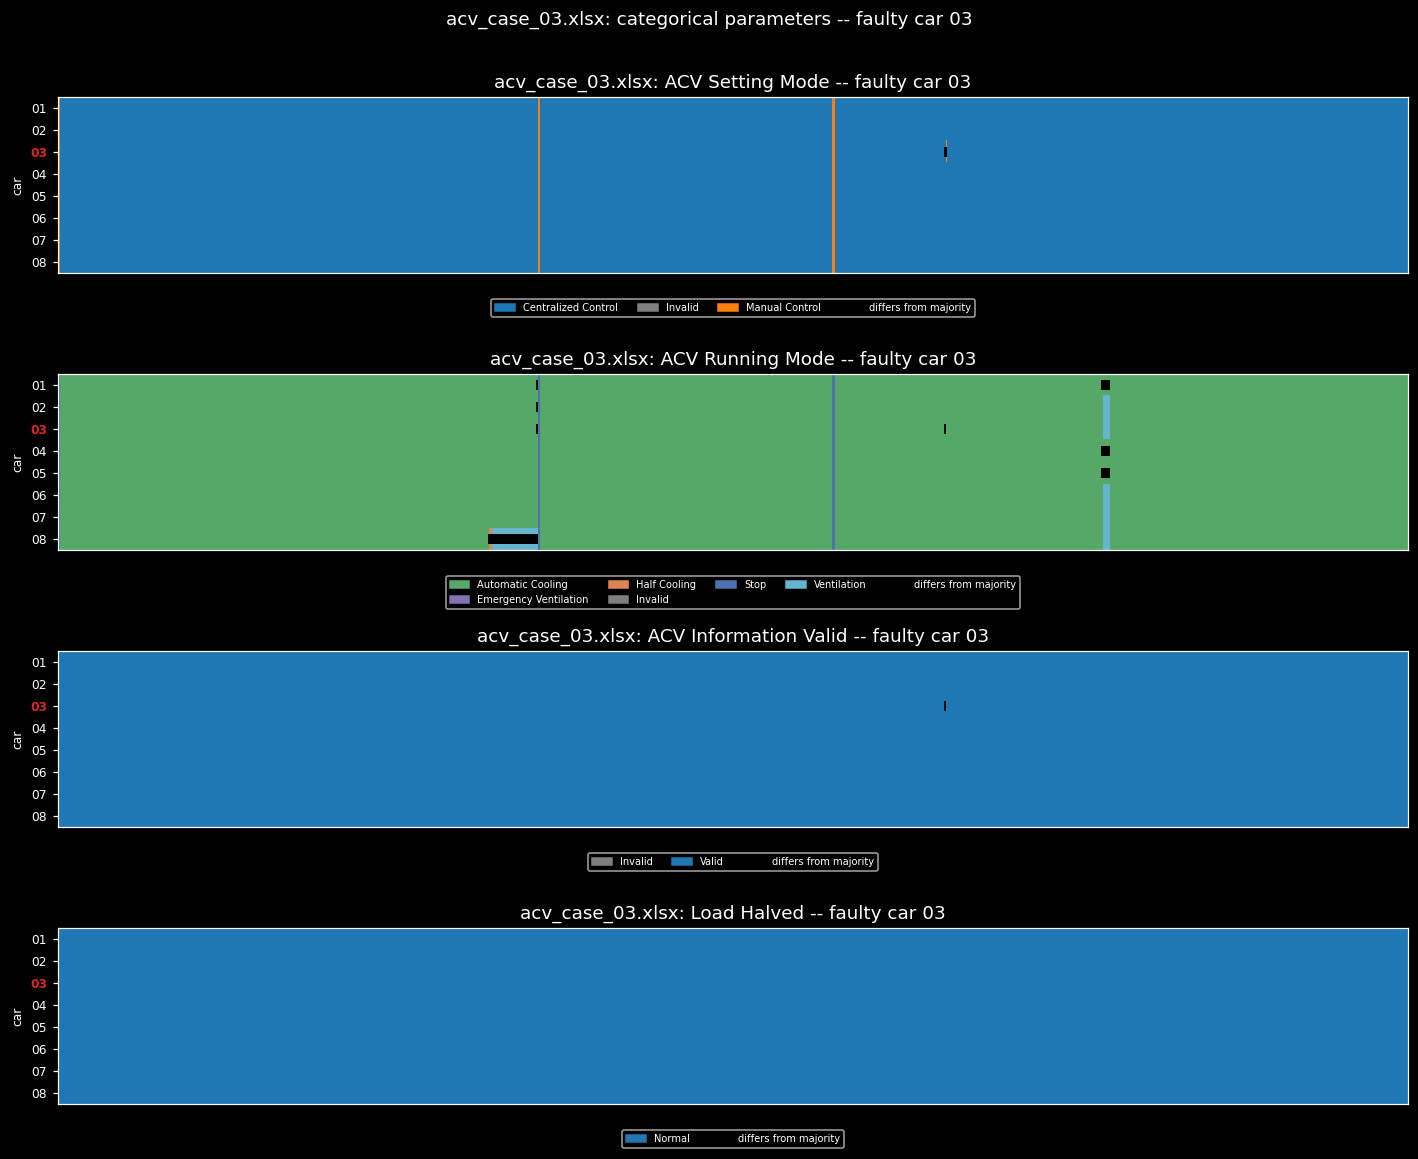

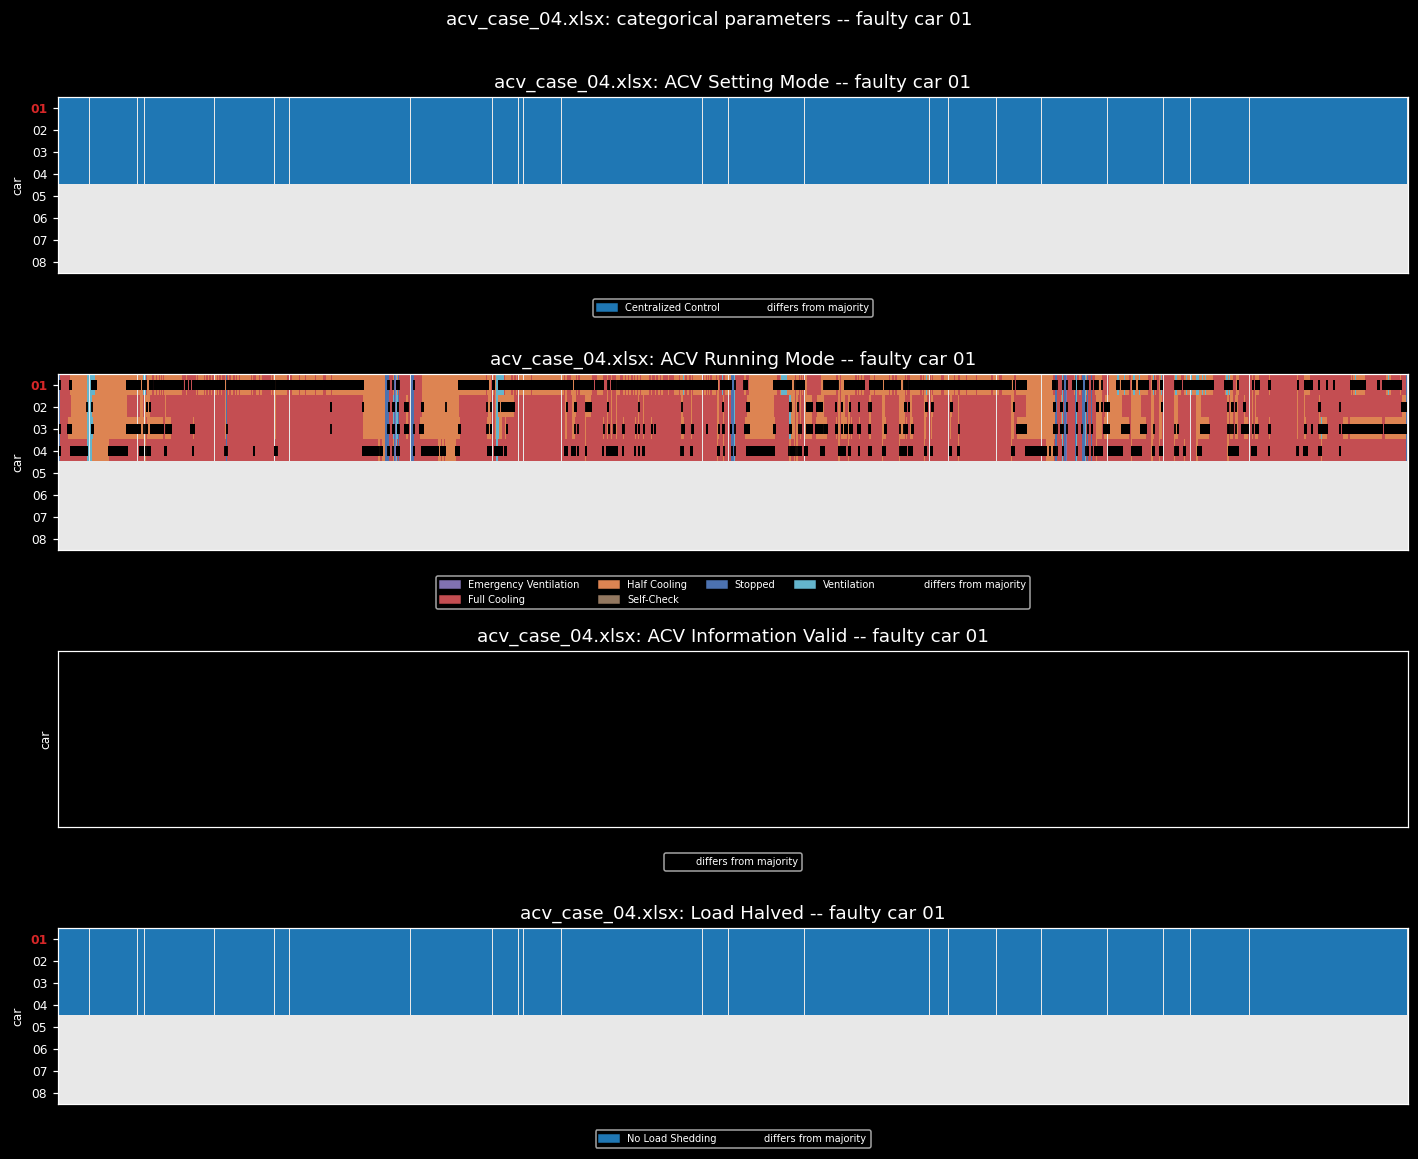

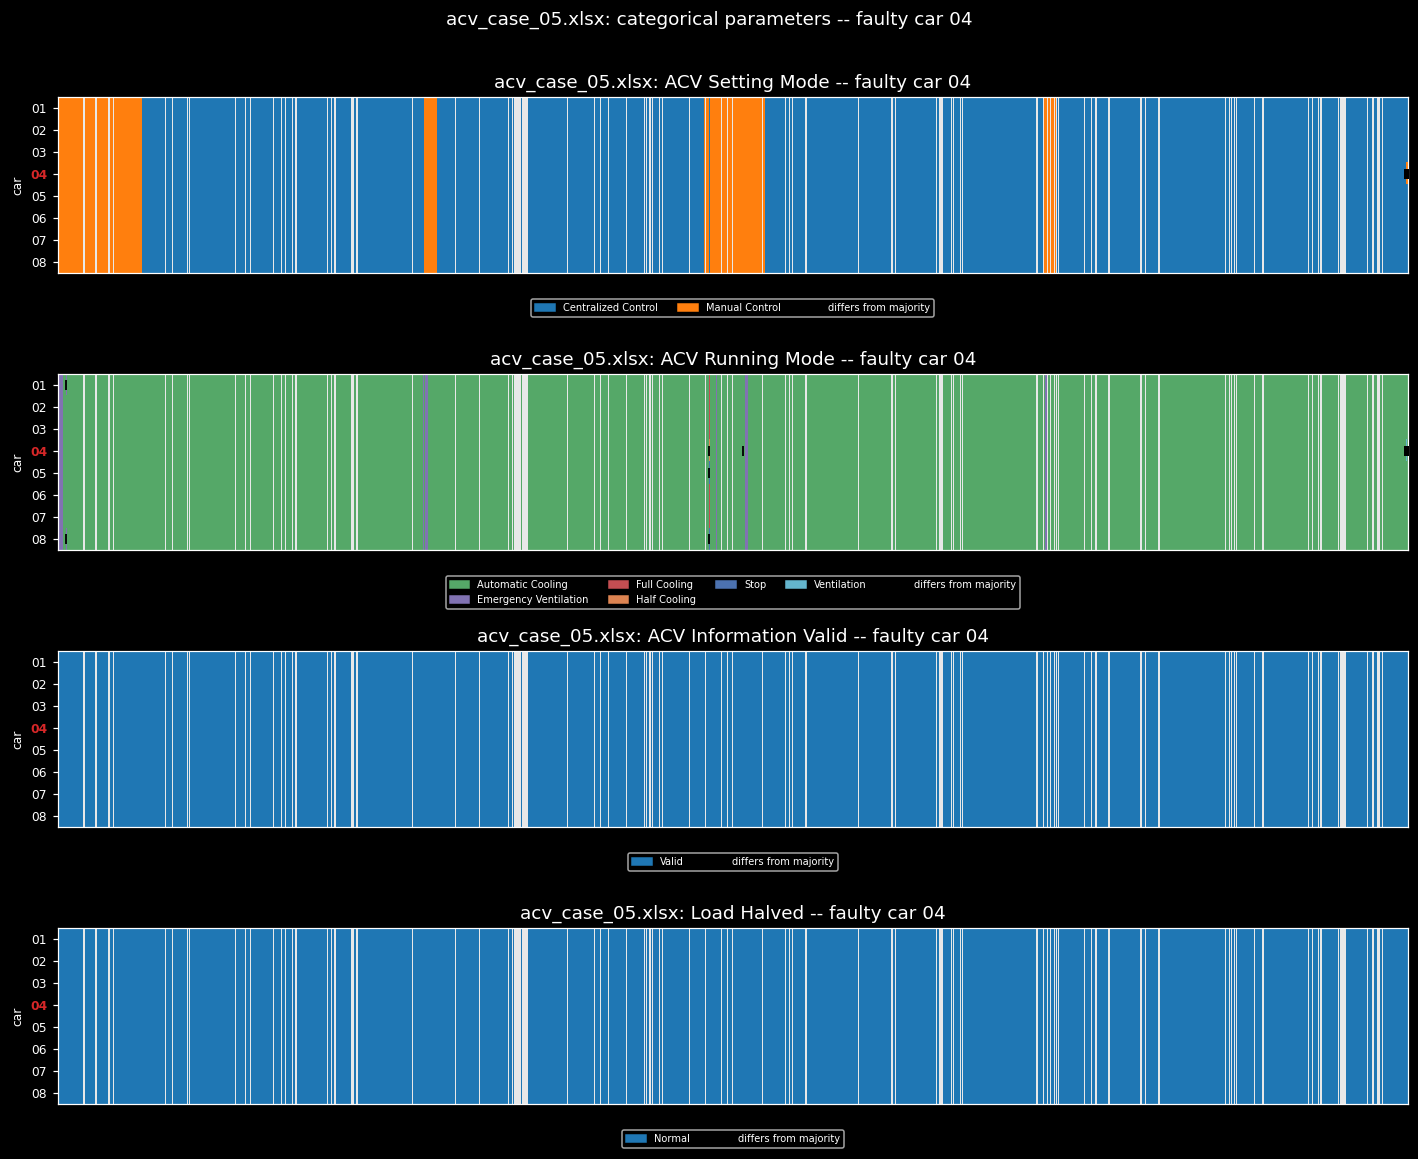

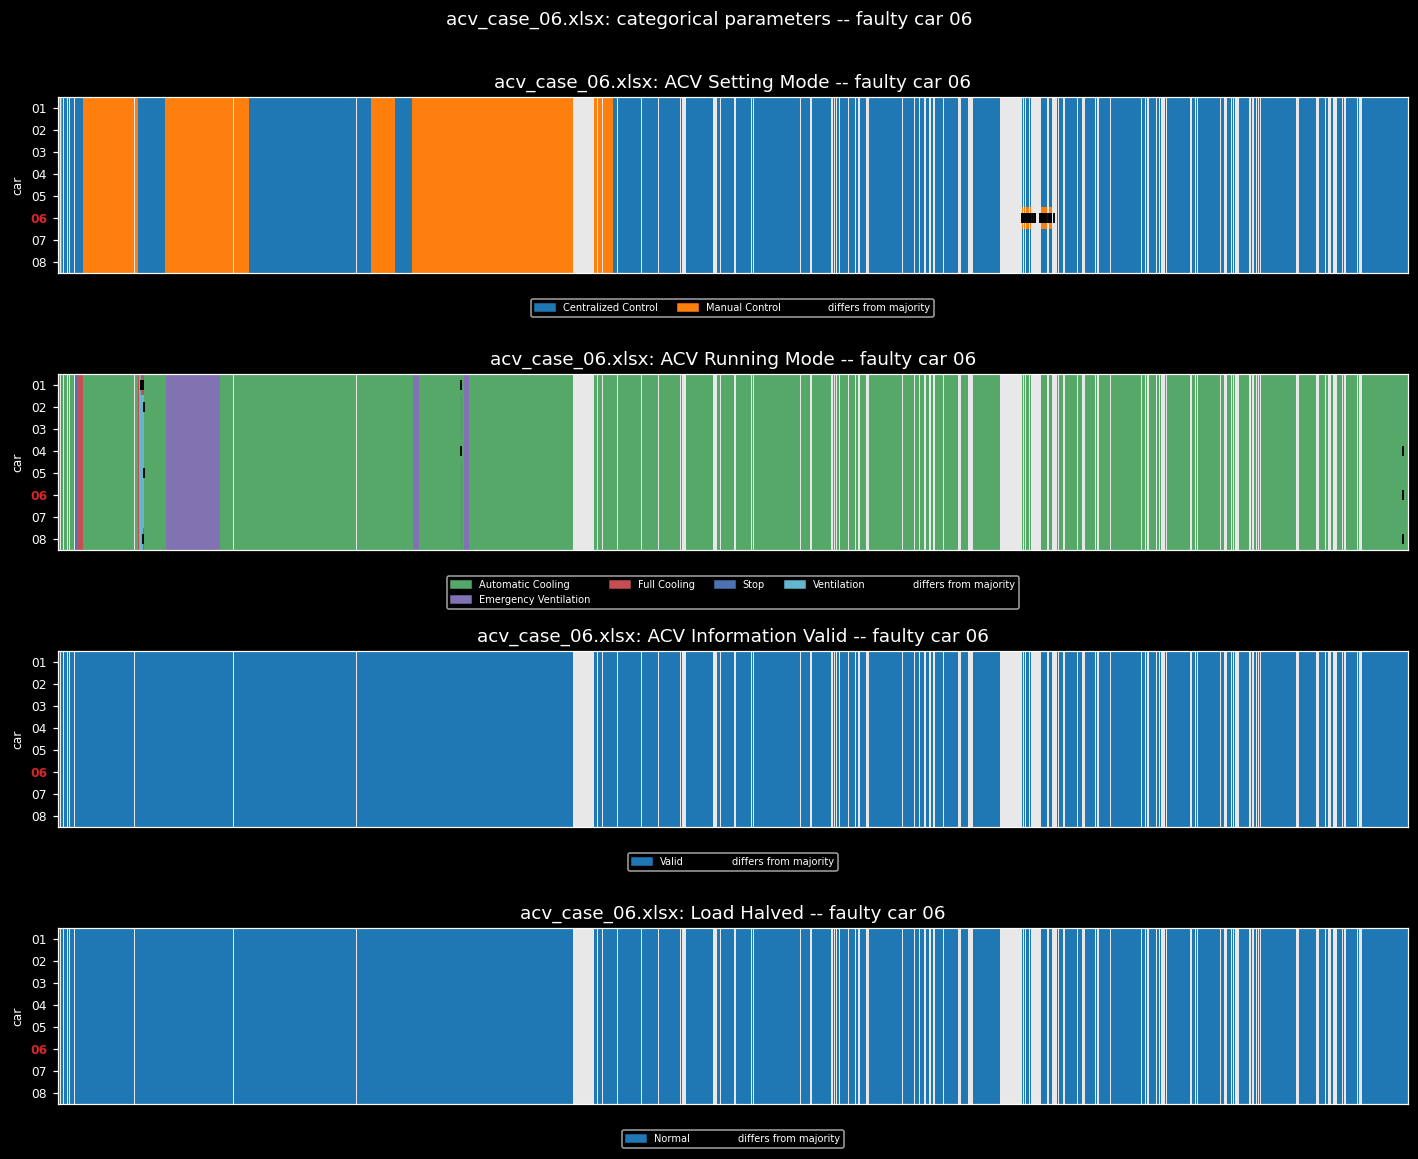

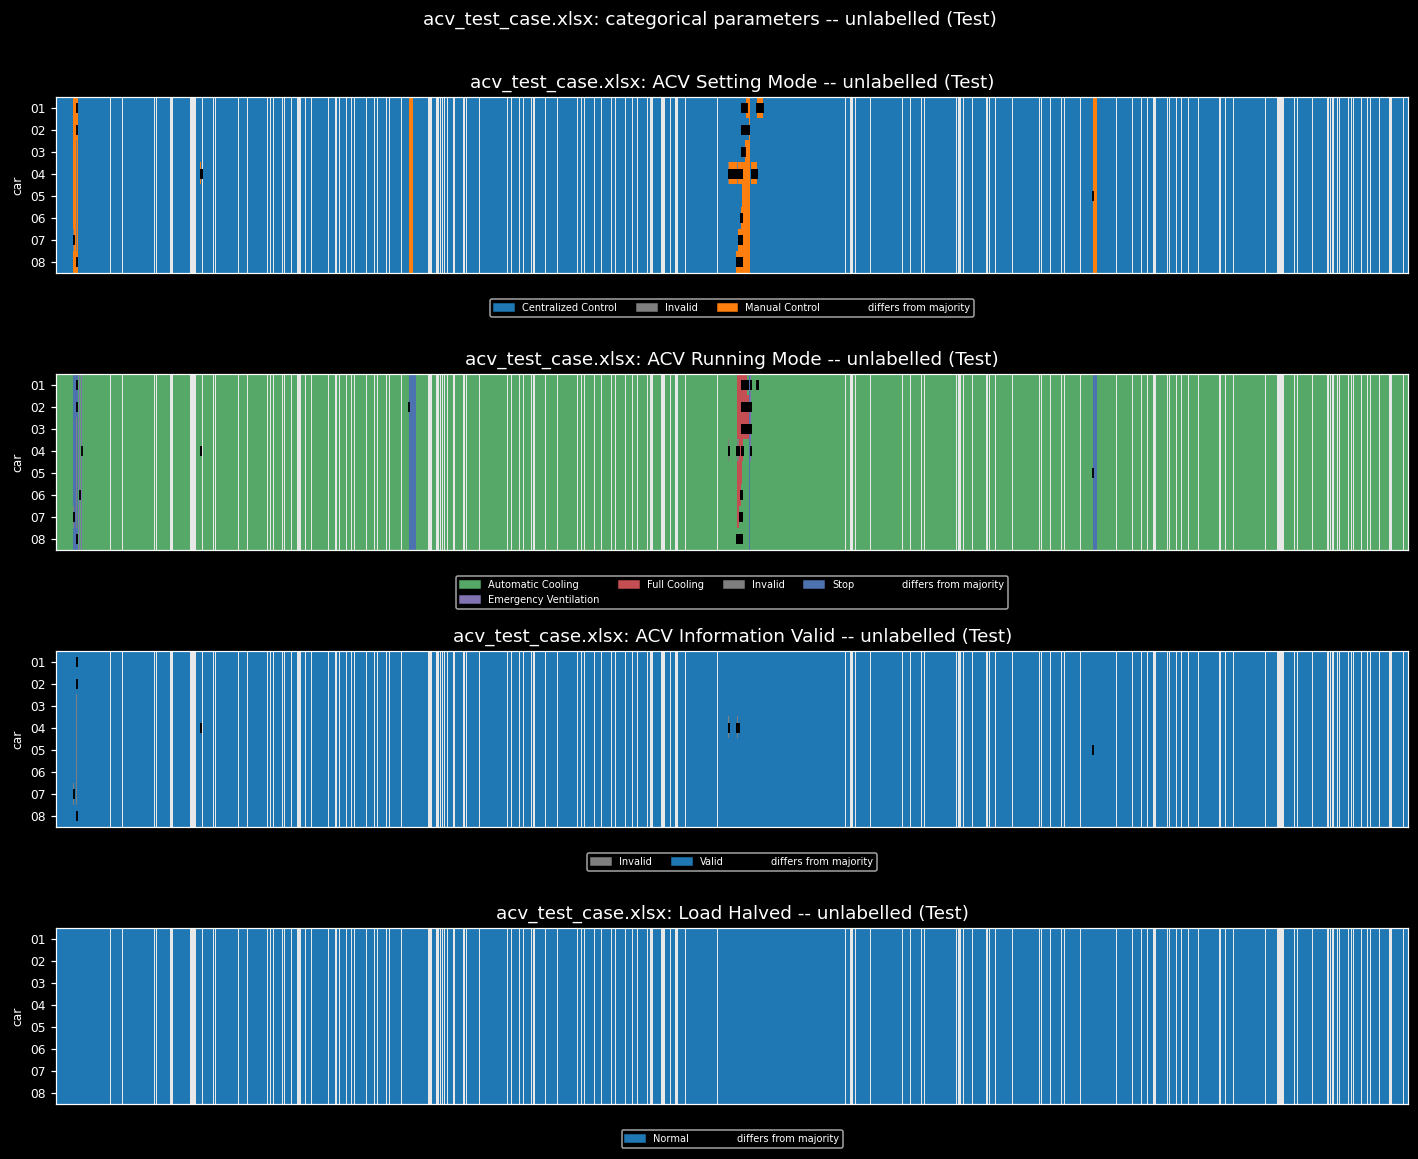

In [88]:
# Every case's four categorical parameters as regime strips -- which car is in
# which state, and when, across the whole labelled set plus Test.
for c in af.ALL_CASES:
    ap.plot_mode_heatmap(c)

## 4. Per-car statistics

`all_car_stats` reduces every (case, car, parameter) to one row: raw statistics plus
residual statistics for numeric parameters, and `frac_majority` (fraction of time this
car agrees with the train-wide majority state) for categorical ones. 7 files × 8 cars ×
up to 8 shared parameters (6 for case 04, which has no equivalent of `ACV Information
Valid` or a separate heating setpoint -- see §1).

In [89]:
stats = af.all_car_stats()
print(stats.shape)
stats.head(10)

(432, 21)


,case,car,param,kind,n,n_missing,mean,std,p05,p50,p95,n_unique,duty,n_switch,resid_mean,resid_std,resid_absmean,resid_p95,frac_majority,faulty_car,is_faulty
0,acv_case_01.xlsx,01,ACV Control Temperature (Cooling),numeric,6999,702,23.970145,1.483962,21.5,24.0,26.0,12,0.335080,41,-0.318803,0.766150,0.324520,2.5,NaN,01,1.0
1,acv_case_01.xlsx,02,ACV Control Temperature (Cooling),numeric,6999,677,23.990747,1.471479,21.5,24.0,26.0,11,0.333913,35,-0.292629,0.731152,0.292629,2.5,NaN,01,0.0
2,acv_case_01.xlsx,03,ACV Control Temperature (Cooling),numeric,6999,677,24.284245,1.209194,22.0,24.0,26.0,11,0.334071,31,0.000870,0.069167,0.000870,0.0,NaN,01,0.0
3,acv_case_01.xlsx,04,ACV Control Temperature (Cooling),numeric,6999,677,24.283376,1.210297,22.0,24.0,26.0,10,0.333913,29,0.000000,0.000000,0.000000,0.0,NaN,01,0.0
4,acv_case_01.xlsx,05,ACV Control Temperature (Cooling),numeric,6999,677,24.283376,1.210297,22.0,24.0,26.0,10,0.333913,29,0.000000,0.000000,0.000000,0.0,NaN,01,0.0
5,acv_case_01.xlsx,06,ACV Control Temperature (Cooling),numeric,6999,677,24.283376,1.210297,22.0,24.0,26.0,10,0.333913,29,0.000000,0.000000,0.000000,0.0,NaN,01,0.0
6,acv_case_01.xlsx,07,ACV Control Temperature (Cooling),numeric,6999,677,24.283376,1.210297,22.0,24.0,26.0,10,0.333913,29,0.000000,0.000000,0.000000,0.0,NaN,01,0.0
7,acv_case_01.xlsx,08,ACV Control Temperature (Cooling),numeric,6999,677,24.283376,1.210297,22.0,24.0,26.0,10,0.333913,29,0.000000,0.000000,0.000000,0.0,NaN,01,0.0
8,acv_case_01.xlsx,01,ACV Control Temperature (Heating),numeric,6999,702,20.000000,0.000000,20.0,20.0,20.0,1,0.000000,0,0.000000,0.000000,0.000000,0.0,NaN,01,1.0
9,acv_case_01.xlsx,02,ACV Control Temperature (Heating),numeric,6999,677,20.000000,0.000000,20.0,20.0,20.0,1,0.000000,0,0.000000,0.000000,0.000000,0.0,NaN,01,0.0


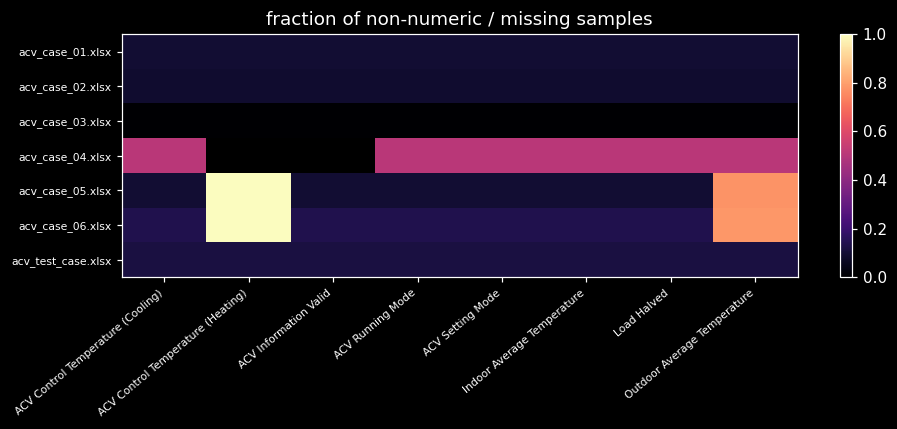

In [90]:
ap.plot_missingness(stats);

In [91]:
# Faulty vs normal cars, pooled over the six labelled cases, per parameter.
# Pooled means hide within-case structure, so read this as a shortlist only.
cols = ["mean", "std", "n_unique", "n_switch", "duty",
        "resid_mean", "resid_absmean", "resid_std", "resid_p95", "frac_majority"]
(stats.dropna(subset=["is_faulty"])
      .groupby(["param", "is_faulty"])[cols]
      .mean()
      .round(3))

mean    std  n_unique  n_switch   duty  resid_mean  resid_absmean  resid_std  resid_p95  frac_majority
param                             is_faulty                                                                                                          
ACV Control Temperature (Cooling) 0.0        23.759  1.330     6.452    31.357  0.292      -0.006          0.058      0.145      0.263            NaN
                                  1.0        23.890  1.360     7.500    55.500  0.280      -0.020          0.142      0.319      0.750            NaN
ACV Control Temperature (Heating) 0.0        20.000  0.000     0.600     0.000  0.000       0.000          0.000      0.000      0.000            NaN
                                  1.0        20.000  0.000     0.600     0.000  0.000       0.000          0.000      0.000      0.000            NaN
ACV Information Valid             0.0           NaN    NaN     1.000     0.000    NaN         NaN            NaN        NaN        NaN          1.000
                                  1.0           NaN    NaN     1.600     3.200    NaN         NaN            NaN        NaN        NaN          0.998
ACV Running Mode                  0.0           NaN    NaN     3.643    29.548    NaN         NaN            NaN        NaN        NaN          0.989
                                  1.0           NaN    NaN     5.000   146.667    NaN         NaN            NaN        NaN        NaN          0.926
ACV Setting Mode                  0.0           NaN    NaN     1.738     7.167    NaN         NaN            NaN        NaN        NaN          0.999
                                  1.0           NaN    NaN     2.333    11.167    NaN         NaN            NaN        NaN        NaN          0.989
Indoor Average Temperature        0.0        23.928  1.591    18.571  1033.571  0.403      -0.039          0.329      0.480      1.000            NaN
                                  1.0        24.561  1.580    18.667  1000.667  0.388       0.507          0.663      0.710      2.000            NaN
Load Halved                       0.0           NaN    NaN     0.905     0.000    NaN         NaN            NaN        NaN        NaN          1.000
                                  1.0           NaN    NaN     1.000     0.000    NaN         NaN            NaN        NaN        NaN          1.000
Outdoor Average Temperature       0.0        31.010  2.528    15.500  1101.881  0.447      -0.030          0.933      0.807      2.036            NaN
                                  1.0        31.621  2.497    15.667  1220.500  0.466       0.100          0.648      0.818      1.750            NaN

In [92]:
# Where the faulty car sits among its own siblings, per case — a within-case
# rank is the comparison the pooled means above cannot make.
def faulty_rank_table(stats, column, ascending=False):
    rows = []
    for (case, param), sub in stats.dropna(subset=["is_faulty"]).groupby(["case", "param"]):
        sub = sub.dropna(subset=[column])
        if sub.empty:
            continue
        order = list(sub.sort_values(column, ascending=ascending)["car"])
        faulty = sub["faulty_car"].iloc[0]
        rows.append({"case": case, "param": param,
                     "rank": order.index(faulty) + 1 if faulty in order else np.nan})
    return (pd.DataFrame(rows)
            .pivot(index="param", columns="case", values="rank"))

faulty_rank_table(stats, "resid_absmean")

case,acv_case_01.xlsx,acv_case_02.xlsx,acv_case_03.xlsx,acv_case_04.xlsx,acv_case_05.xlsx,acv_case_06.xlsx
param,,,,,,
ACV Control Temperature (Cooling),1.0,1.0,5.0,2.0,4.0,6.0
ACV Control Temperature (Heating),1.0,2.0,3.0,NaN,NaN,NaN
Indoor Average Temperature,1.0,1.0,1.0,4.0,2.0,1.0
Outdoor Average Temperature,2.0,3.0,5.0,1.0,NaN,NaN


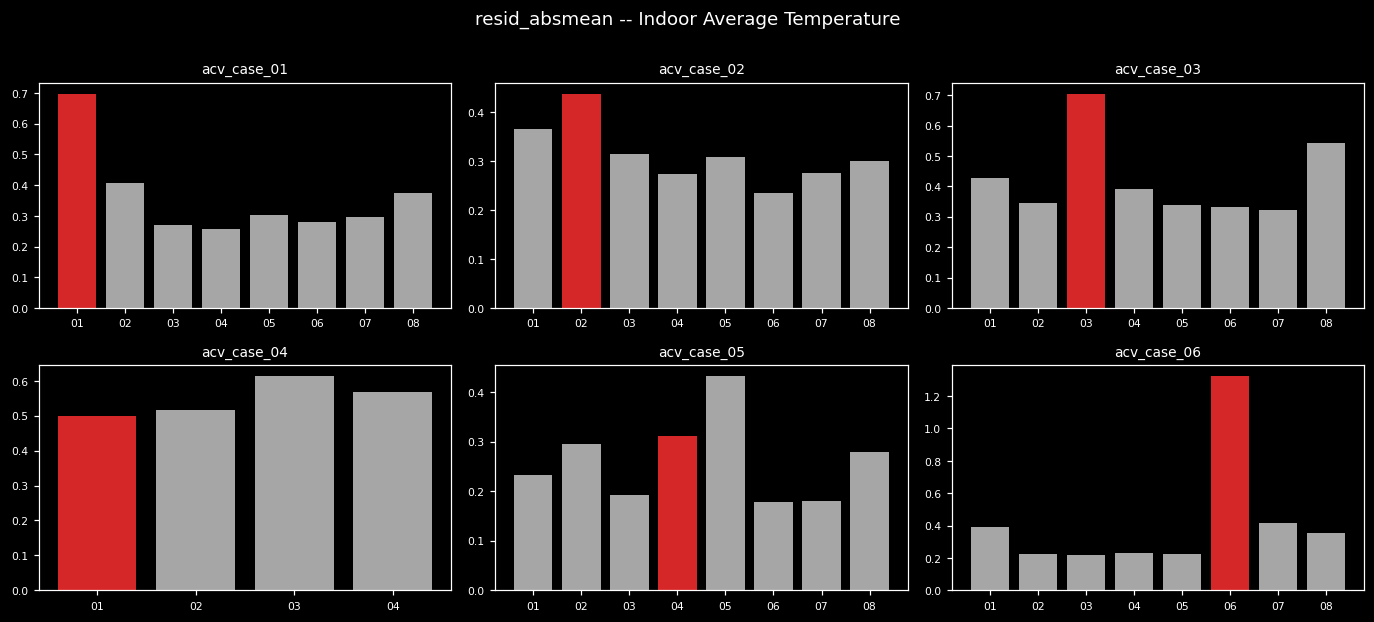

In [93]:
ap.plot_stat_by_car(stats, "resid_absmean", "Indoor Average Temperature",
                    cases=af.TRAIN_CASES);

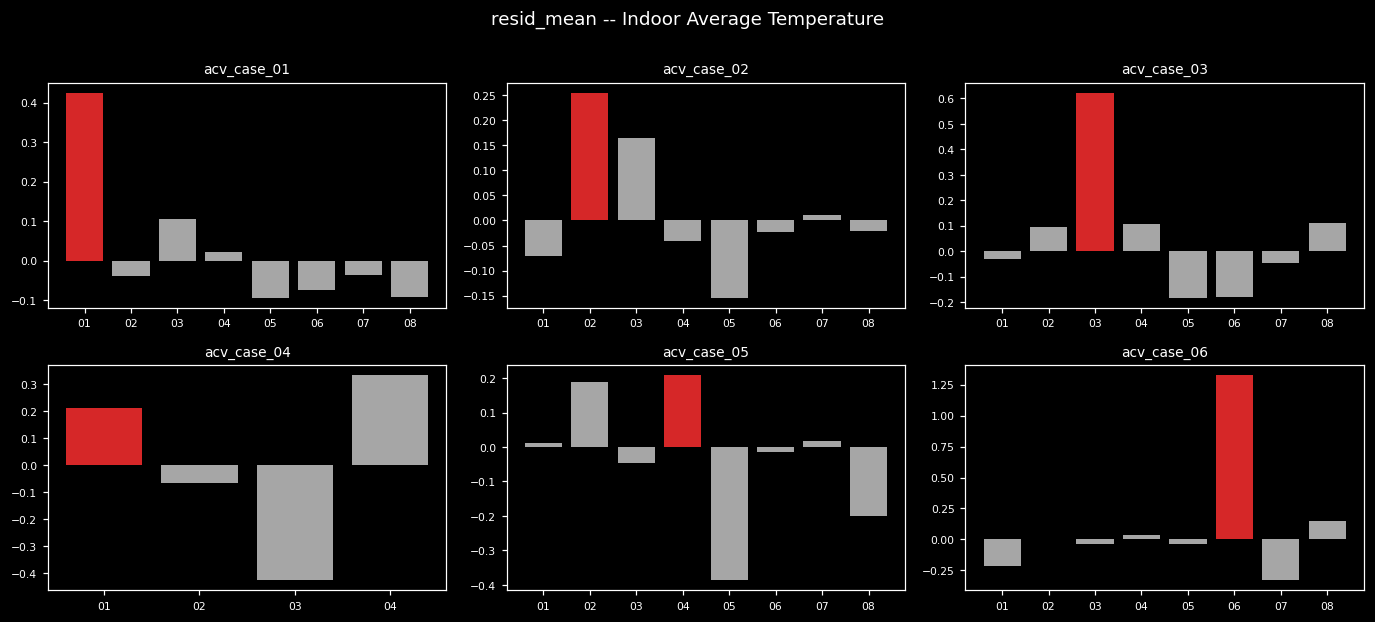

In [94]:
ap.plot_stat_by_car(stats, "resid_mean", "Indoor Average Temperature",
                    cases=af.TRAIN_CASES);

### Regime agreement

`frac_majority` is the categorical analogue of a residual: what fraction of the time this
car's state agrees with the train-wide majority state at the same instant. Since the
running-mode command is centralized (~89% of timestamps have all 8 cars sharing one mode
-- see `acv_features`'s module docstring), a car that disagrees more often is a car whose
own local thermostat is crossing the hysteresis threshold at different moments than its
siblings -- consistent with degraded cooling capacity.

In [95]:
faulty_rank_table(stats, "frac_majority", ascending=True)

case,acv_case_01.xlsx,acv_case_02.xlsx,acv_case_03.xlsx,acv_case_04.xlsx,acv_case_05.xlsx,acv_case_06.xlsx
param,,,,,,
ACV Information Valid,1.0,1.0,1.0,NaN,4.0,6.0
ACV Running Mode,1.0,1.0,5.0,1.0,1.0,5.0
ACV Setting Mode,1.0,1.0,1.0,1.0,1.0,1.0
Load Halved,1.0,2.0,3.0,1.0,4.0,6.0


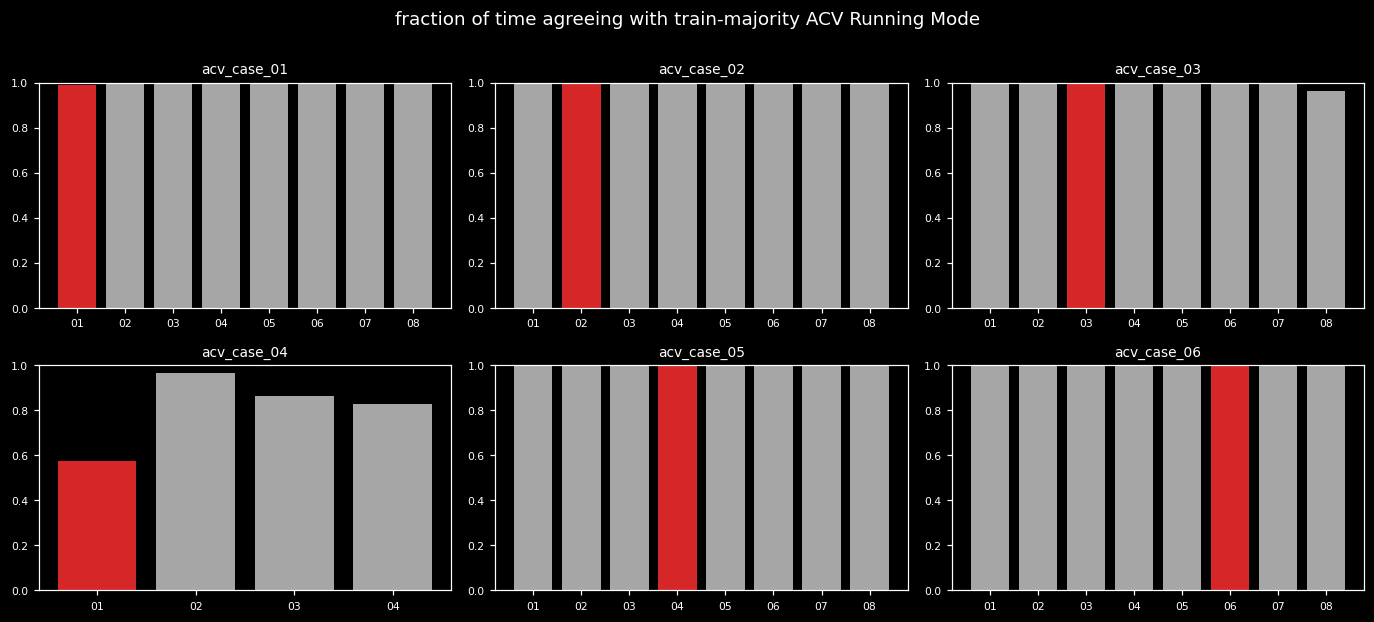

In [96]:
ap.plot_regime_share(stats, "ACV Running Mode", cases=af.TRAIN_CASES);

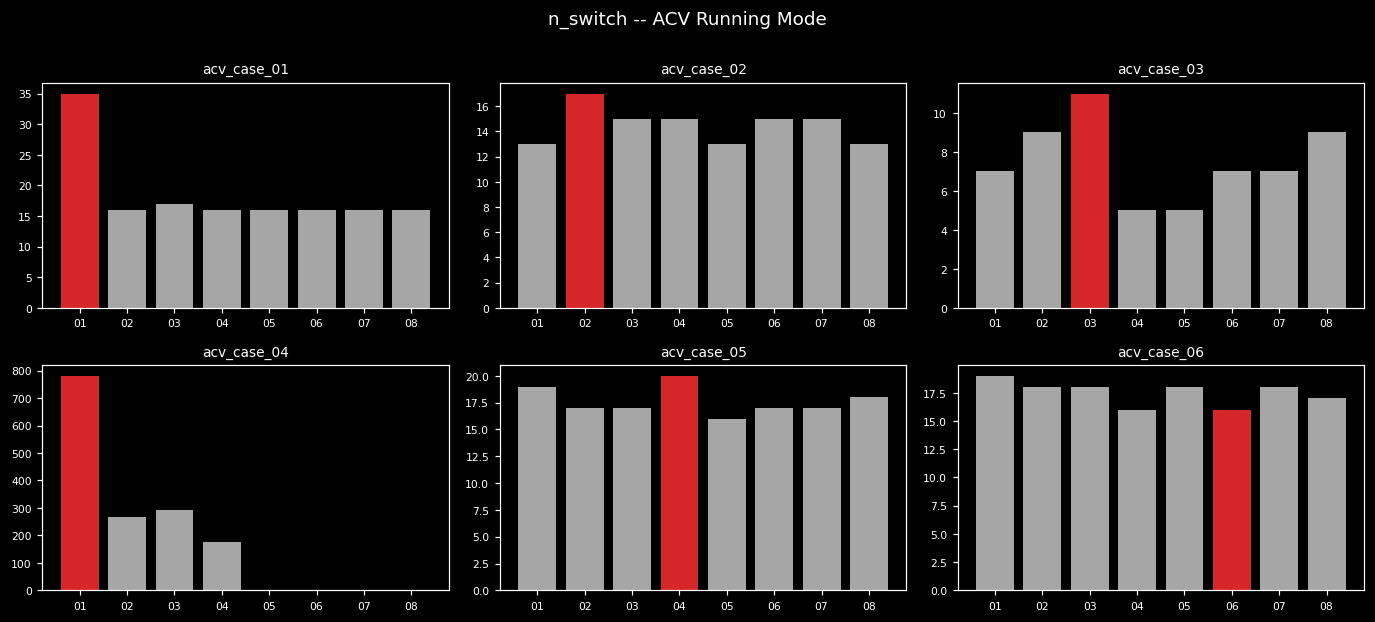

In [97]:
ap.plot_stat_by_car(stats, "n_switch", "ACV Running Mode",
                    cases=af.TRAIN_CASES);

## 5. Single-statistic ranking rules, scored

Every (parameter × statistic × direction) turned into an 8-car ranking and scored with the
official `(n − (r − 1)) / n`, averaged over the six labelled cases. A **random ranking
averages 0.5625**, so absolute height means little — the gap above the dashed line is the
only interesting quantity, and with n = 6 cases a single lucky case moves the mean by 0.07.
Rules built on a parameter that almost never changes (`ACV Setting Mode`) can reach a
perfect score on very few real transitions -- read those as a shortlist to scrutinise, not
a settled result.

In [98]:
summary, per_case = af.rank_sweep(stats)
summary.head(25)

,param,stat,ascending,mean_score,n_top1,mean_rank,n_cases
0,ACV Setting Mode,frac_majority,True,1.000000,6,1.000000,6
1,ACV Setting Mode,n_switch,False,1.000000,6,1.000000,6
2,Indoor Average Temperature,resid_mean,False,0.958333,5,1.166667,6
3,Indoor Average Temperature,mean,False,0.958333,5,1.166667,6
4,Indoor Average Temperature,resid_p95,False,0.937500,5,1.500000,6
5,ACV Running Mode,n_unique,False,0.895833,5,1.833333,6
6,ACV Control Temperature (Heating),resid_absmean,True,0.875000,1,2.000000,3
7,ACV Control Temperature (Heating),resid_absmean,False,0.875000,1,2.000000,3
8,ACV Control Temperature (Heating),duty,False,0.875000,1,2.000000,3
9,ACV Control Temperature (Heating),duty,True,0.875000,1,2.000000,3


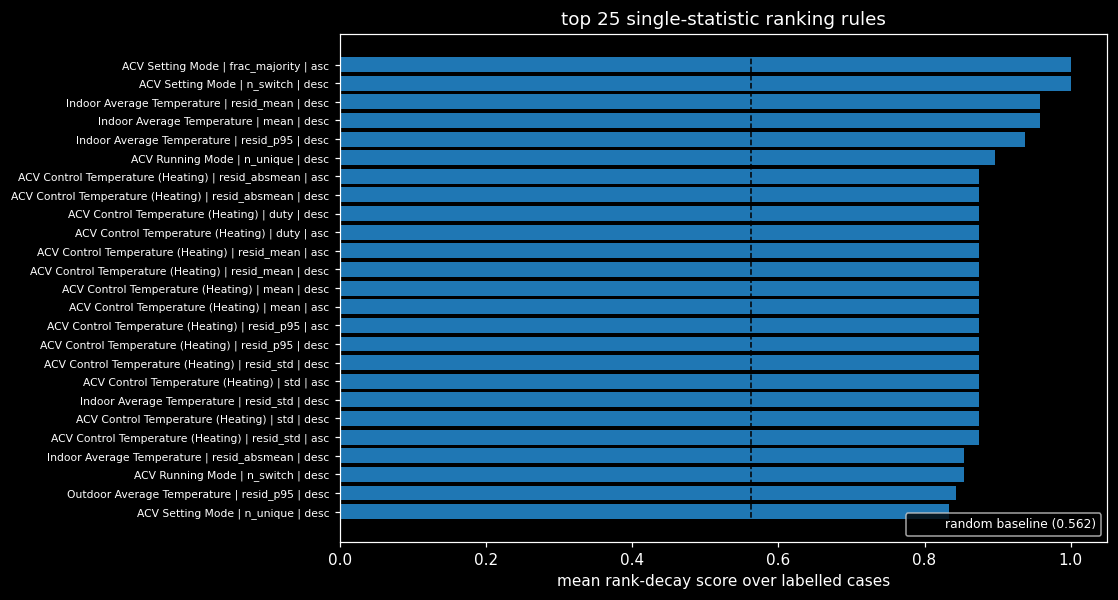

In [99]:
ap.plot_rank_summary(summary, top=25);

In [100]:
# Per-case detail for the sweep's current leader: a rule that wins on average by
# acing two cases and missing four is not the same as one that is consistently
# second, even though both can show the same mean.
best = summary.iloc[0]
(per_case[(per_case["param"] == best["param"]) &
          (per_case["stat"] == best["stat"]) &
          (per_case["ascending"] == best["ascending"])]
 [["case", "faulty_car", "ranked_cars", "rank", "score"]])

,case,faulty_car,ranked_cars,rank,score
493,acv_case_01.xlsx,01,01|03|07|02|04|05|06|08,1.0,1.0
494,acv_case_02.xlsx,02,02|08|07|01|03|06|04|05,1.0,1.0
495,acv_case_03.xlsx,03,03|01|02|04|05|06|07|08,1.0,1.0
496,acv_case_04.xlsx,01,01|02|03|04,1.0,1.0
497,acv_case_05.xlsx,04,04|01|02|03|05|06|07|08,1.0,1.0
498,acv_case_06.xlsx,06,06|01|03|02|04|05|07|08,1.0,1.0
499,acv_test_case.xlsx,NaN,04|01|02|08|07|03|06|05,NaN,NaN


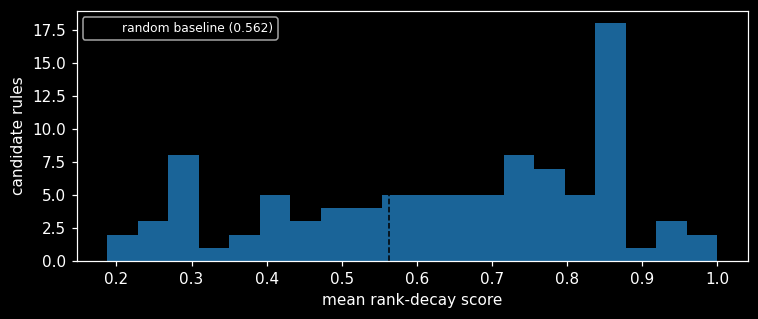

In [101]:
# Distribution of scores across all candidate rules, against the baseline.
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(summary["mean_score"], bins=20, color="tab:blue", alpha=0.85)
ax.axvline(ap.RANDOM_BASELINE, color="k", ls="--", lw=1,
           label=f"random baseline ({ap.RANDOM_BASELINE:.3f})")
ax.set_xlabel("mean rank-decay score")
ax.set_ylabel("candidate rules")
ax.legend(fontsize=8)
fig.tight_layout()

### The mode-conditioned cooling gap

The strongest *physically motivated* rule found: per car, `Indoor − ACV Control
Temperature (Cooling)` restricted to rows where that car's own `ACV Running Mode` is a
cooling state (`cooling_gap_stats`). Because the decision to cool is centralized and
shared by all 8 cars (see `acv_features`'s module docstring), this isolates how well each
car's own compressor executes an identical, externally-imposed command -- exactly what a
refrigerant leak degrades. It needs a numeric and a categorical parameter of the same car
at once, which the one-parameter-at-a-time shape of `car_stats`/`rank_sweep` above cannot
express, so it is scored separately here.

In [102]:
cg = af.all_cooling_gap_stats(cases=af.TRAIN_CASES)

rows = []
for case, sub in cg.dropna(subset=["cooling_gap_mean"]).groupby("case"):
    sub = sub.sort_values("cooling_gap_mean", ascending=False)
    order = list(sub["car"])
    faulty = sub["faulty_car"].iloc[0]
    n = len(order)
    rank = order.index(faulty) + 1
    rows.append({"case": case, "faulty_car": faulty,
                 "ranked_cars": "|".join(order), "rank": rank,
                 "score": (n - (rank - 1)) / n})
cooling_gap_scores = pd.DataFrame(rows)
print("mean score:", cooling_gap_scores["score"].mean().round(3))
cooling_gap_scores

mean score: 0.958


,case,faulty_car,ranked_cars,rank,score
0,acv_case_01.xlsx,01,01|02|03|04|07|08|05|06,1,1.00
1,acv_case_02.xlsx,02,02|03|07|08|06|01|04|05,1,1.00
2,acv_case_03.xlsx,03,03|02|01|07|04|08|05|06,1,1.00
3,acv_case_04.xlsx,01,04|01|03|02,2,0.75
4,acv_case_05.xlsx,04,04|02|07|01|06|03|08|05,1,1.00
5,acv_case_06.xlsx,06,06|08|04|02|03|05|01|07,1,1.00


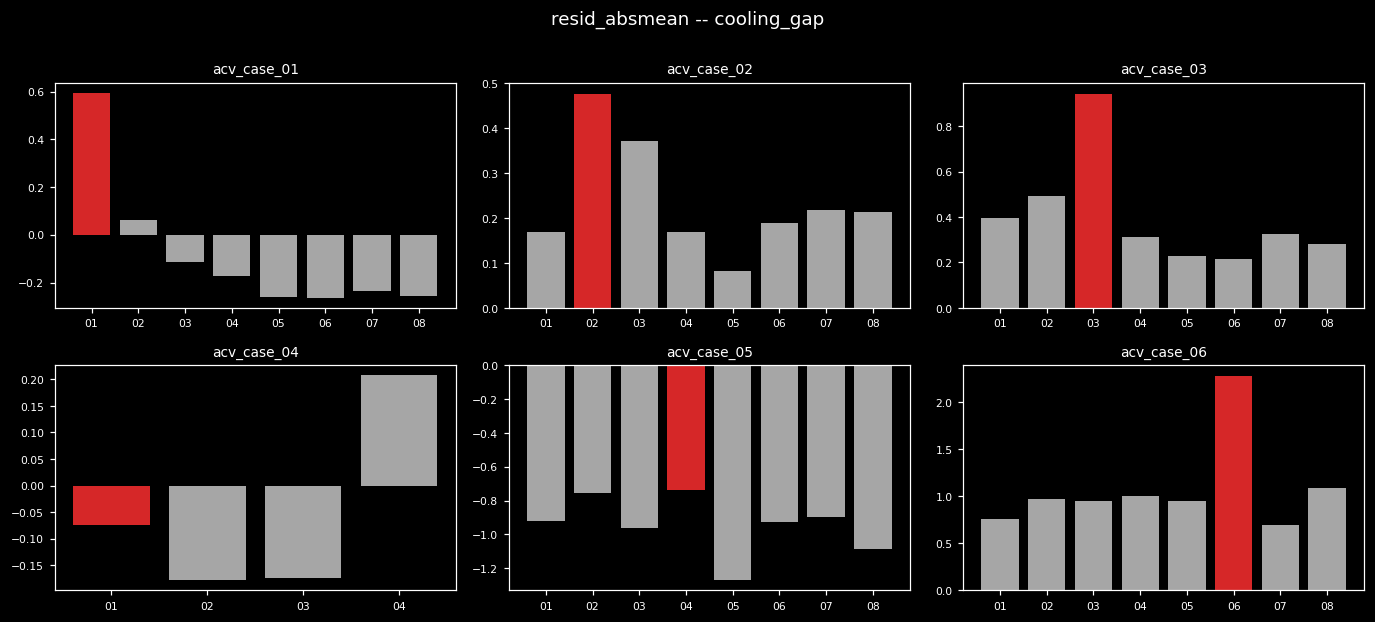

In [103]:
ap.plot_stat_by_car(
    cg.rename(columns={"cooling_gap_mean": "resid_absmean"}).assign(param="cooling_gap"),
    "resid_absmean", "cooling_gap", cases=af.TRAIN_CASES);

## 6. Test case

Same views on the unlabelled file, purely as a sanity check that it looks like the Train
cases and that nothing in the pipeline silently degrades on it. No car is highlighted,
since there is no published label.

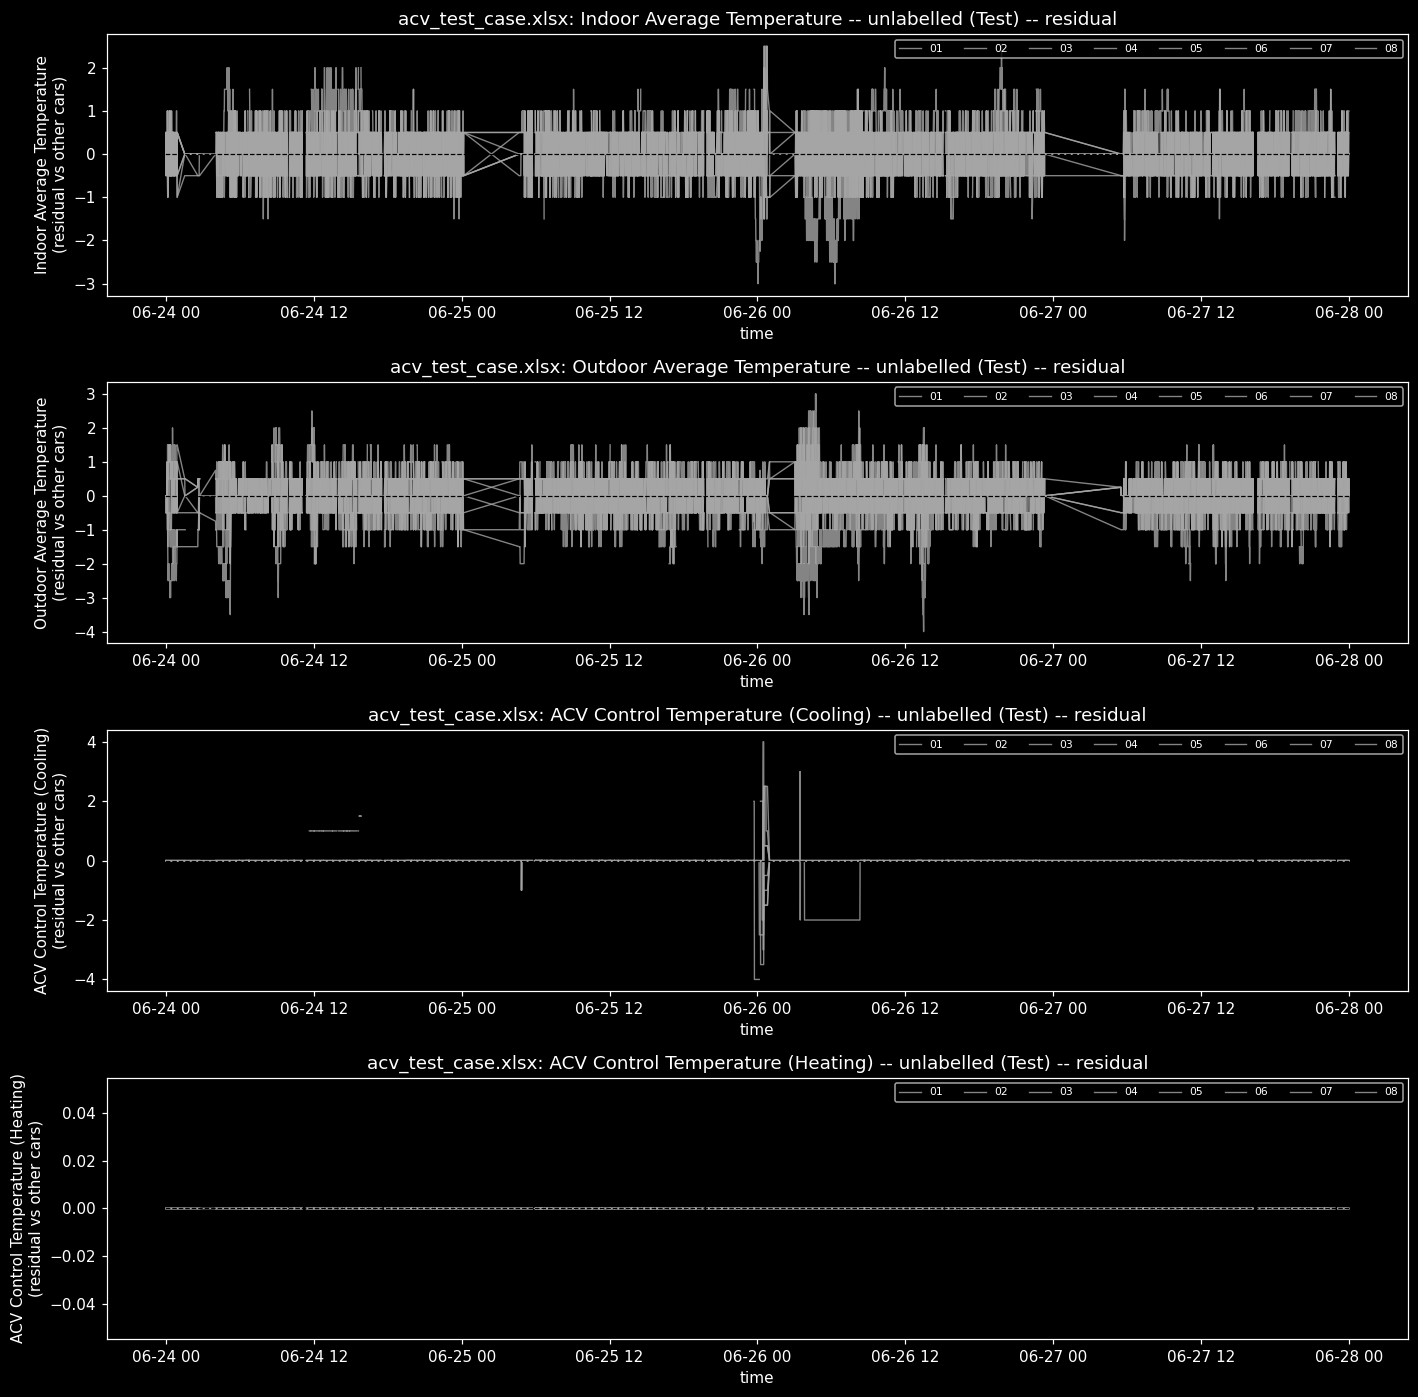

In [104]:
test_long = af.with_majority_reference(af.with_train_reference(af.to_long("acv_test_case.xlsx")))

fig, axes = plt.subplots(len(af.NUMERIC_PARAMS), 1,
                         figsize=(13, 3.2 * len(af.NUMERIC_PARAMS)))
for ax, param in zip(axes, af.NUMERIC_PARAMS):
    ap.plot_residual_timeline("acv_test_case.xlsx", param=param,
                              long=test_long, ax=ax)
fig.tight_layout()

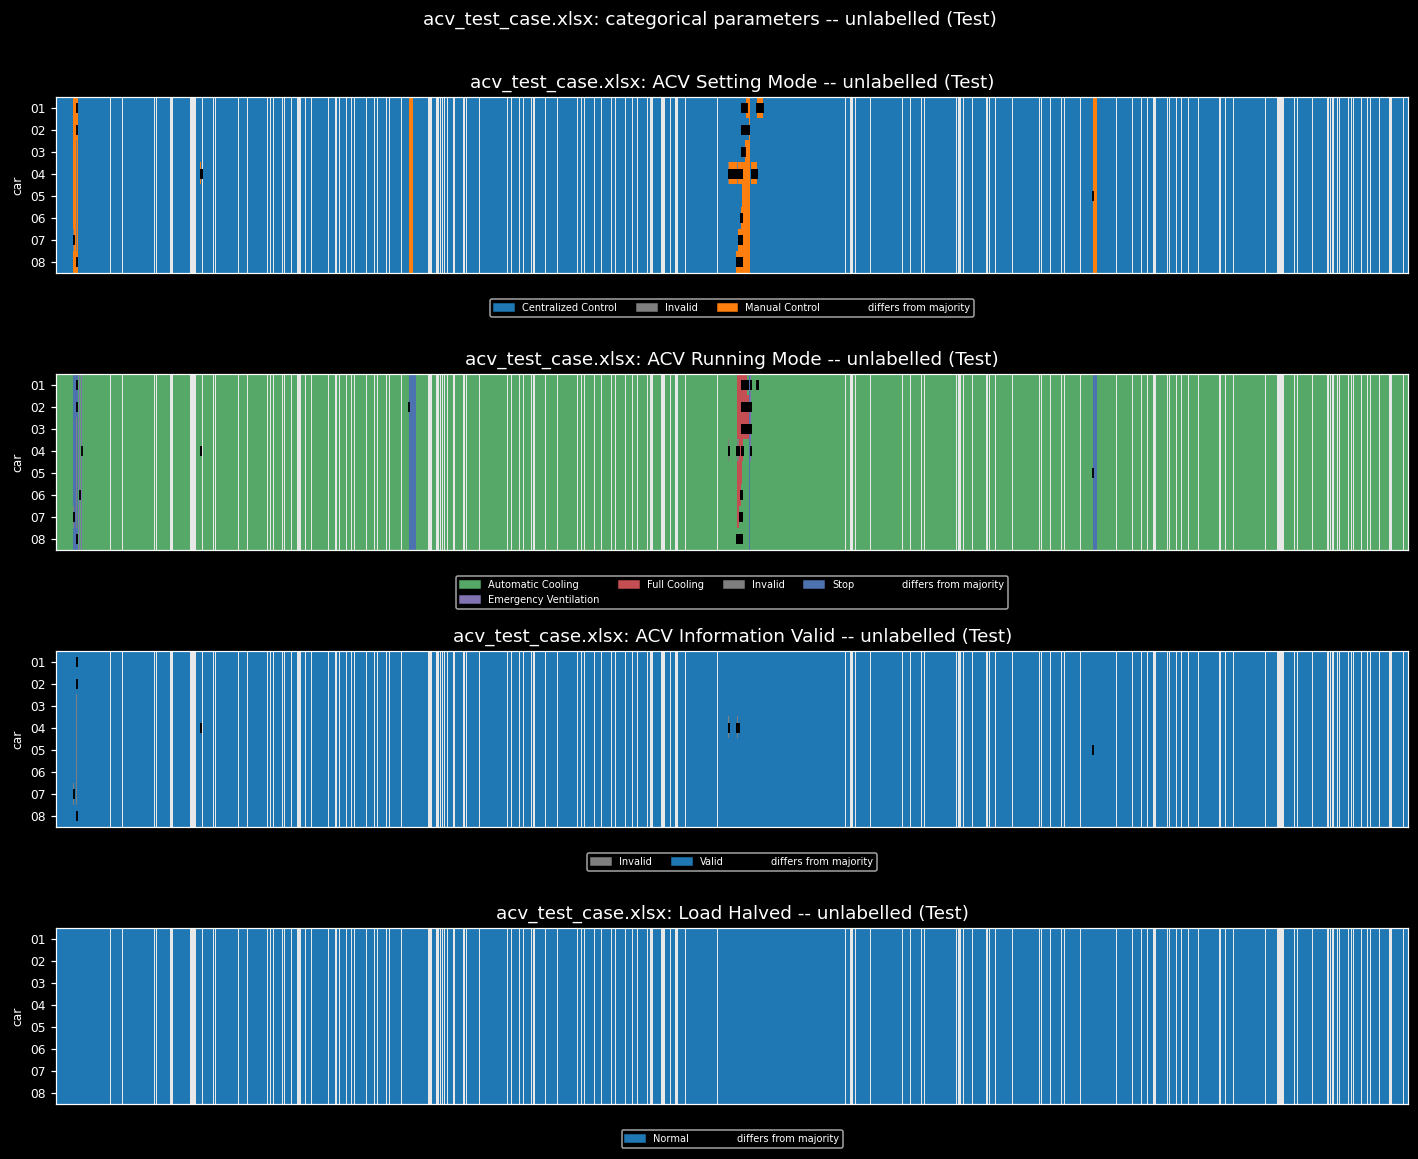

In [105]:
ap.plot_mode_heatmap("acv_test_case.xlsx", long=test_long);

In [106]:
stats[stats["case"] == "acv_test_case.xlsx"].pivot(
    index="car", columns="param", values="resid_absmean").round(3)

param,ACV Control Temperature (Cooling),ACV Control Temperature (Heating),ACV Information Valid,ACV Running Mode,ACV Setting Mode,Indoor Average Temperature,Load Halved,Outdoor Average Temperature
car,,,,,,,,
01,0.147,0.0,NaN,NaN,NaN,0.473,NaN,0.419
02,0.014,0.0,NaN,NaN,NaN,0.280,NaN,0.373
03,0.007,0.0,NaN,NaN,NaN,0.254,NaN,0.398
04,0.094,0.0,NaN,NaN,NaN,0.285,NaN,0.326
05,0.008,0.0,NaN,NaN,NaN,0.264,NaN,0.296
06,0.006,0.0,NaN,NaN,NaN,0.239,NaN,0.278
07,0.021,0.0,NaN,NaN,NaN,0.243,NaN,0.363
08,0.016,0.0,NaN,NaN,NaN,0.309,NaN,0.610


In [107]:
af.cooling_gap_stats("acv_test_case.xlsx").sort_values("cooling_gap_mean", ascending=False)

,case,car,n_cooling,cooling_gap_mean,cooling_gap_std,cooling_gap_max
0,acv_test_case.xlsx,01,7872,0.124619,0.775306,5.0
2,acv_test_case.xlsx,03,7872,-0.053100,0.776865,5.5
6,acv_test_case.xlsx,07,7876,-0.075609,0.794683,5.0
3,acv_test_case.xlsx,04,7854,-0.078113,0.776692,4.5
7,acv_test_case.xlsx,08,7876,-0.088370,0.744588,4.5
5,acv_test_case.xlsx,06,7875,-0.113460,0.758398,5.0
1,acv_test_case.xlsx,02,7871,-0.172977,0.744590,5.5
4,acv_test_case.xlsx,05,7876,-0.184675,0.719051,4.5
